# Taller B4-T1 — Diseño de Redes Confiables (Justicia e Incertidumbre)

**Notebook combinado del equipo.** Reúne en un solo documento las partes del taller:

- **EDA ampliado de dependencias** y **Tarea 1 — Capa customizada** (`MonotonicDebtRiskLayer`): *Emilio*.
- **Tarea 2 — Aprendizaje Justo (Fair Loss)** y **Tarea 4 — Incertidumbre** (error-predictor): *eglezarr*.

Predecimos `TARGET` (1 = impago, 0 = paga) de *Home Credit Default Risk*; variable **sensible**: `CODE_GENDER`.

> **Nota de montaje:** fusión *por secciones*, conservando el pipeline de cada autor. **Todas las secciones
> leen la misma fuente** (`data/application_train.csv`, dataset completo) y usan el **mismo split estratificado
> 80/10/10**. Cada parte mantiene su propia ingeniería de features: EDA + Tarea 1 con `load_home_credit`
> (layout `[8 features | 3 financieras crudas]` que necesita la capa custom) y Justicia + Incertidumbre con
> `cargar_datos_fair` (*flags* de missingness y vistas Base/Fair). La **Tarea 3 (AutoML)** no está aquí (queda
> en el notebook completo). Pensado para **Colab** (TensorFlow + Keras 3).

## 0. Configuración y librerías

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import keras
from keras import layers, ops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score

# --- Ruta al CSV de Home Credit (application_train.csv) ---
_cand = ["data/application_train.csv",
         os.path.expanduser("~/TallerB4-T1/data/application_train.csv"),
         "application_train.csv",
         "/content/application_train.csv",
         os.path.expanduser("~/Downloads/application_train.csv")]
CSV_PATH = next((p for p in _cand if os.path.exists(p)), _cand[0])

SEED = 42
SUBSAMPLE = None     # dataset COMPLETO (misma fuente para todas las secciones); pon un nº para iterar rápido
EPOCHS = 25
BATCH = 256
os.makedirs("outputs", exist_ok=True)

keras.utils.set_random_seed(SEED); np.random.seed(SEED)
print("Keras:", keras.__version__, "| backend:", keras.config.backend())
print("CSV_PATH =", CSV_PATH, "| existe:", os.path.exists(CSV_PATH))

Keras: 3.14.1 | backend: numpy
CSV_PATH = data/application_train.csv | existe: True


## 1. Carga y preprocesado de datos

Loader basado en el del esqueleto del taller, con tres mejoras:
- **Guarda el nº de `EXT_SOURCE` ausentes por persona ANTES de imputar** (proxy de calidad → incertidumbre).
- **Imputa también `AMT_ANNUITY`** (el loader original dejaba 12 NaN → rompía el entrenamiento).
- **Split estratificado 3-way** train/val/test ≈ **80/10/10** (mismo % de impago en los tres), reproducible con `seed`.
- **Medianas y escalado ajustados sólo con TRAIN** (sin fuga hacia val/test). Protocolo: **validación** para elegir hiperparámetros (p. ej. `λ`) y **test** sólo para el reporte final.

`X` final = `[8 features escaladas | 3 financieras crudas positivas]`. Las 3 crudas las usa la
capa customizada para calcular ratios (necesitan ser positivas).

In [2]:
BASE_FEATURES = ['CODE_GENDER','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',
                 'AGE_YEARS','EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
RAW_FIN  = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY']     # positivos -> ratios en la capa custom
EXT_COLS = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']

def load_home_credit(path, subsample=None, seed=SEED):
    cols = ['TARGET','CODE_GENDER','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','DAYS_BIRTH'] + EXT_COLS
    df = pd.read_csv(path, usecols=cols)
    if subsample:
        df = df.sample(n=min(subsample, len(df)), random_state=seed).reset_index(drop=True)

    # nº de EXT_SOURCE ausentes ANTES de imputar (clave para la incertidumbre)
    n_missing_ext = df[EXT_COLS].isna().sum(axis=1).values.astype('int32')

    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M':0,'F':1}).fillna(0).astype('float32')  # sensible
    df['AGE_YEARS']   = df['DAYS_BIRTH'].abs() / 365.0

    y = df['TARGET'].astype('float32').values
    s = df['CODE_GENDER'].astype('float32').values

    # Split estratificado 3-way (train/val/test ≈ 80/10/10), reproducible y sin solape
    idx = np.arange(len(df))
    tr_val, te = train_test_split(idx, test_size=0.10, random_state=seed, stratify=y)
    tr, va = train_test_split(tr_val, test_size=0.10/0.90, random_state=seed, stratify=y[tr_val])

    feat = df[BASE_FEATURES].astype('float32')
    raw  = df[RAW_FIN].astype('float32')
    feat = feat.fillna(feat.iloc[tr].median())      # imputa medianas de TRAIN (incl. AMT_ANNUITY)
    raw  = raw.fillna(raw.iloc[tr].median())

    scaler = StandardScaler().fit(feat.iloc[tr].values)
    Xb   = scaler.transform(feat.values).astype('float32')   # features escaladas
    Xraw = raw.values.astype('float32')                      # positivas, sin escalar
    X = np.hstack([Xb, Xraw]).astype('float32')              # [8 | 3] = 11 columnas

    return dict(X_train=X[tr], X_val=X[va], X_test=X[te],
                y_train=y[tr], y_val=y[va], y_test=y[te],
                s_train=s[tr], s_val=s[va], s_test=s[te],
                nmiss_train=n_missing_ext[tr], nmiss_val=n_missing_ext[va],
                nmiss_test=n_missing_ext[te], n_base=len(BASE_FEATURES))

data = load_home_credit(CSV_PATH, subsample=SUBSAMPLE)
X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']
s_train, s_val, s_test = data['s_train'], data['s_val'], data['s_test']
N_BASE = data['n_base']
print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape, "| n_base:", N_BASE)

pos = y_train.mean()
cw = {0: 1.0, 1: float((1 - pos) / pos)}     # class_weight para el desbalanceo
print(f"Impagos en train: {pos:.3%} | class_weight = {{0:1.0, 1:{cw[1]:.2f}}}")

X_train: (246007, 11) | X_val: (30752, 11) | X_test: (30752, 11) | n_base: 8
Impagos en train: 8.073% | class_weight = {0:1.0, 1:11.39}


## 2. Análisis exploratorio ampliado de dependencias

Esta sección integra el contenido de `EDA_dependencias.ipynb` en el notebook entregable. Usa las tablas completas de Home Credit descargadas en `data/` y guarda las figuras en `outputs/eda/`.

### 2.0 Configuración y utilidades

In [3]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["figure.autolayout"] = False

DATA = "data"
OUT  = "outputs/eda"
os.makedirs(OUT, exist_ok=True)

C = dict(good="#55A868", bad="#C44E52", m="#4C72B0", f="#DD8452",
         neu="#8172B3", acc="#CCB974")

def savefig(name, fig=None):
    (fig or plt.gcf()).tight_layout()
    plt.savefig(f"{OUT}/{name}.png", dpi=120, bbox_inches="tight")
    plt.show()

def decile_default(x, y, q=10):
    # Tasa de impago media por cuantil de x (deciles por defecto)
    d = pd.DataFrame({"x": np.asarray(x, float), "y": np.asarray(y, float)}).dropna()
    d["bin"] = pd.qcut(d["x"], q, duplicates="drop")
    g = d.groupby("bin", observed=True)["y"].agg(["mean", "count"])
    g.index = [f"{iv.left:.3g}" for iv in g.index]
    return g

def cramers_v(x, y):
    # V de Cramér (asociación entre dos categóricas), corregida
    ct = pd.crosstab(x, y)
    if ct.shape[0] < 2 or ct.shape[1] < 2: return np.nan
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum(); r, k = ct.shape
    phi2 = chi2 / n
    phi2c = max(0, phi2 - (r-1)*(k-1)/(n-1))
    rc = r - (r-1)**2/(n-1); kc = k - (k-1)**2/(n-1)
    return np.sqrt(phi2c / max(min(rc-1, kc-1), 1e-9))

print("Librerías OK. Figuras ->", OUT)

Librerías OK. Figuras -> outputs/eda


### 2.1 Carga de `application_train` + variables derivadas

Cargamos un subconjunto **curado** de columnas con significado (demografía, finanzas,
fuentes externas y señales de comportamiento), evitando las ~50 columnas de edificio
(`*_AVG/_MODE/_MEDI`), casi vacías. Derivamos edad, antigüedad laboral, los **ratios
financieros** y el **nº de `EXT_SOURCE` ausentes**.

In [4]:
USE = ['SK_ID_CURR','TARGET','CODE_GENDER','NAME_CONTRACT_TYPE','FLAG_OWN_CAR',
 'FLAG_OWN_REALTY','CNT_CHILDREN','CNT_FAM_MEMBERS','AMT_INCOME_TOTAL','AMT_CREDIT',
 'AMT_ANNUITY','AMT_GOODS_PRICE','NAME_INCOME_TYPE','NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','OCCUPATION_TYPE','ORGANIZATION_TYPE',
 'REGION_POPULATION_RELATIVE','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH','DAYS_LAST_PHONE_CHANGE','OWN_CAR_AGE','REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY','EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3',
 'OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','AMT_REQ_CREDIT_BUREAU_YEAR',
 'REG_CITY_NOT_WORK_CITY']

df = pd.read_csv(f"{DATA}/application_train.csv", usecols=USE)

# nº de EXT_SOURCE ausentes ANTES de imputar (proxy de calidad de fuentes externas)
EXT = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
df['N_EXT_MISSING'] = df[EXT].isna().sum(axis=1).astype(int)

# variables derivadas
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365.25)
emp = df['DAYS_EMPLOYED'].replace(365243, np.nan)   # 365243 = centinela de pensionistas
df['EMPLOY_YEARS'] = (-emp / 365.25)
df['GENDER_F'] = df['CODE_GENDER'].map({'M':0,'F':1})   # XNA -> NaN

# ratios financieros (los que calcula la capa custom + un par más)
df['CREDIT_INCOME']  = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_CREDIT'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
df['CREDIT_GOODS']   = df['AMT_CREDIT']  / df['AMT_GOODS_PRICE']
df['INCOME_PER_FAM'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, np.nan)

GLOBAL_DR = df['TARGET'].mean()
print("application_train:", df.shape, "| nº columnas usadas:", len(USE))
print(f"Tasa global de impago: {GLOBAL_DR:.3%}")
df[['AGE_YEARS','EMPLOY_YEARS','CREDIT_INCOME','ANNUITY_INCOME','N_EXT_MISSING']].describe().round(2)

application_train: (307511, 43) | nº columnas usadas: 34
Tasa global de impago: 8.073%


,AGE_YEARS,EMPLOY_YEARS,CREDIT_INCOME,ANNUITY_INCOME,N_EXT_MISSING
count,307511.00,252137.00,307511.00,307499.00,307511.00
mean,43.91,6.53,3.96,0.18,0.76
std,11.95,6.40,2.69,0.09,0.65
min,20.50,-0.00,0.00,0.00,0.00
25%,33.98,2.10,2.02,0.11,0.00
50%,43.12,4.51,3.27,0.16,1.00
75%,53.89,8.69,5.16,0.23,1.00
max,69.07,49.04,84.74,1.88,3.00


### 2.2 Panorama del dataset y desbalanceo de `TARGET`

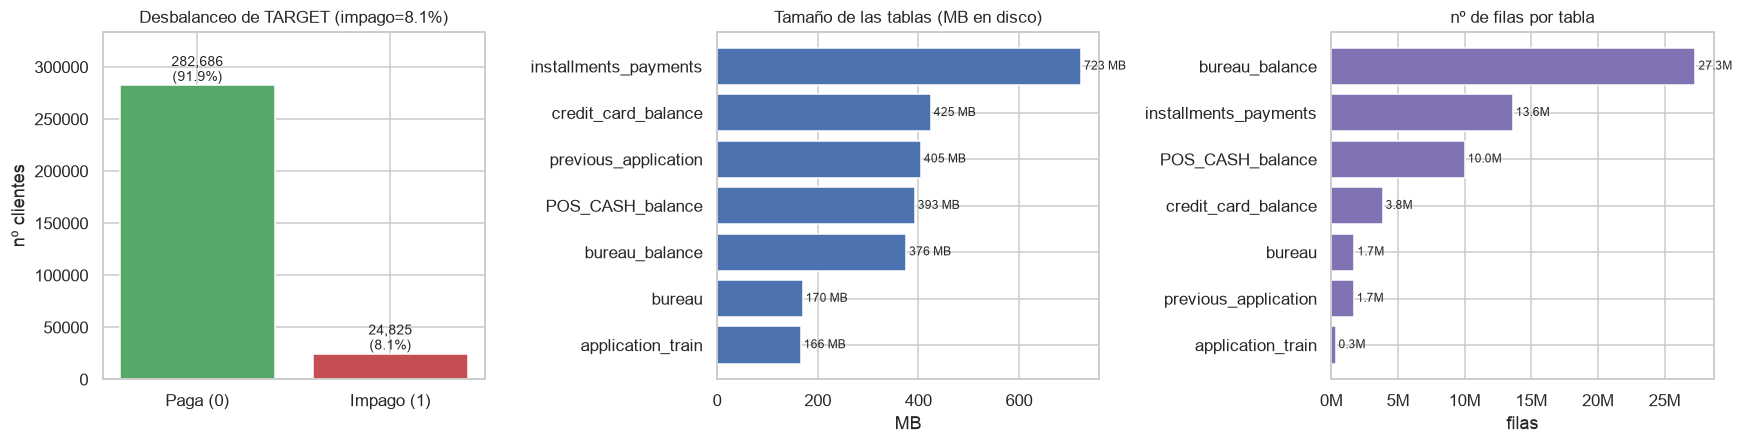

filas por tabla: {'application_train': '307,511', 'bureau': '1,716,428', 'bureau_balance': '27,299,925', 'previous_application': '1,670,214', 'POS_CASH_balance': '10,001,358', 'installments_payments': '13,605,401', 'credit_card_balance': '3,840,312'}


In [5]:
tables = ['application_train','bureau','bureau_balance','previous_application',
          'POS_CASH_balance','installments_payments','credit_card_balance']
sizes = {t: os.path.getsize(f"{DATA}/{t}.csv")/1e6 for t in tables}

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
# (a) desbalanceo de TARGET
vc = df['TARGET'].value_counts().sort_index()
ax[0].bar(['Paga (0)','Impago (1)'], vc.values, color=[C['good'], C['bad']])
for i,v in enumerate(vc.values):
    ax[0].text(i, v, f"{v:,}\n({v/vc.sum():.1%})", ha='center', va='bottom', fontsize=9)
ax[0].set_title(f"Desbalanceo de TARGET (impago={GLOBAL_DR:.1%})"); ax[0].set_ylabel("nº clientes")
ax[0].margins(y=0.18)

# (b) tamaño de cada tabla en disco
tn = sorted(sizes, key=sizes.get)
ax[1].barh(tn, [sizes[t] for t in tn], color=C['m'])
for i,t in enumerate(tn): ax[1].text(sizes[t], i, f" {sizes[t]:.0f} MB", va='center', fontsize=8)
ax[1].set_title("Tamaño de las tablas (MB en disco)"); ax[1].set_xlabel("MB")

# (c) nº de filas (lectura barata por conteo de líneas)
def nrows(t):
    with open(f"{DATA}/{t}.csv") as fh:
        return sum(1 for _ in fh) - 1
rows = {t: nrows(t) for t in tables}
tn2 = sorted(rows, key=rows.get)
ax[2].barh(tn2, [rows[t] for t in tn2], color=C['neu'])
for i,t in enumerate(tn2): ax[2].text(rows[t], i, f" {rows[t]/1e6:.1f}M", va='center', fontsize=8)
ax[2].set_title("nº de filas por tabla"); ax[2].set_xlabel("filas")
ax[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
savefig("01_panorama")
print("filas por tabla:", {t: f"{r:,}" for t,r in rows.items()})

### 2.3 Datos ausentes

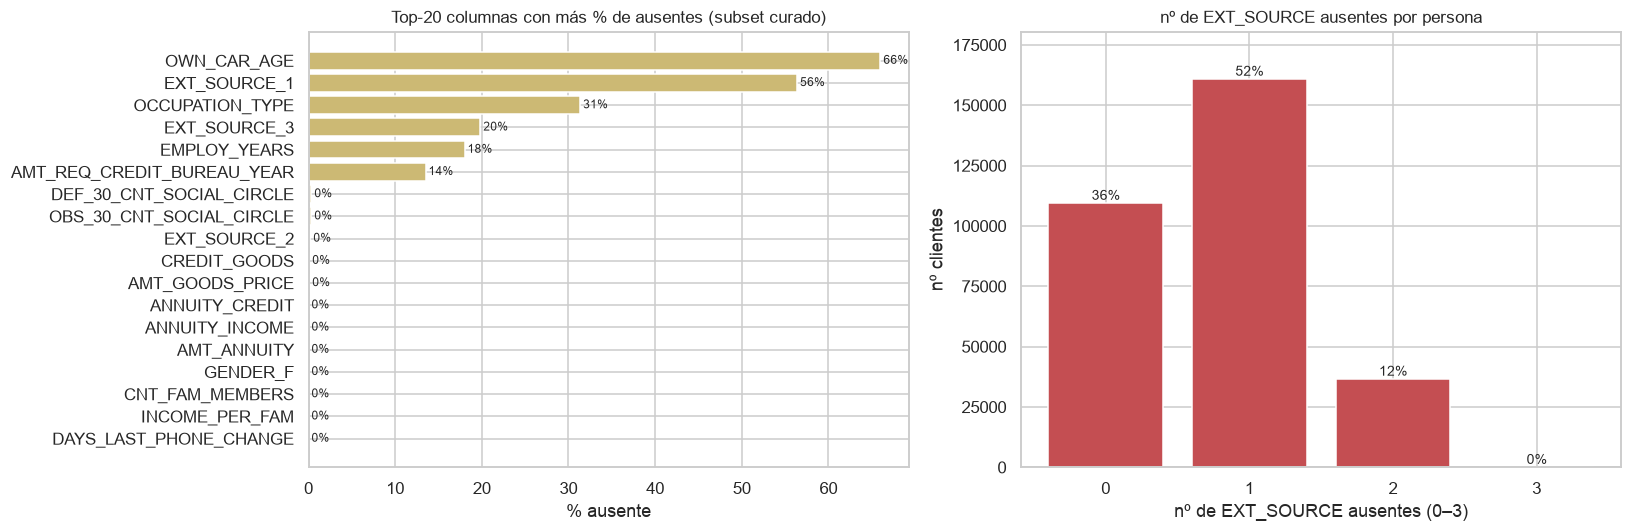

EXT_SOURCE_1 ausente: 56.4% | EXT_SOURCE_3: 19.8%


In [6]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
top = miss.head(20)[::-1]
ax[0].barh(top.index, top.values*100, color=C['acc'])
for i,v in enumerate(top.values): ax[0].text(v*100, i, f" {v:.0%}", va='center', fontsize=8)
ax[0].set_title("Top-20 columnas con más % de ausentes (subset curado)")
ax[0].set_xlabel("% ausente")

# EXT_SOURCE: cuántos faltan por persona y su frecuencia
nm = df['N_EXT_MISSING'].value_counts().sort_index()
ax[1].bar(nm.index.astype(str), nm.values, color=C['bad'])
for i,(k,v) in enumerate(nm.items()):
    ax[1].text(i, v, f"{v/len(df):.0%}", ha='center', va='bottom', fontsize=9)
ax[1].set_title("nº de EXT_SOURCE ausentes por persona")
ax[1].set_xlabel("nº de EXT_SOURCE ausentes (0–3)"); ax[1].set_ylabel("nº clientes")
ax[1].margins(y=0.12)
savefig("02_ausentes")
print("EXT_SOURCE_1 ausente:", f"{df['EXT_SOURCE_1'].isna().mean():.1%}",
      "| EXT_SOURCE_3:", f"{df['EXT_SOURCE_3'].isna().mean():.1%}")

### 2.4 Distribuciones de variables clave, separadas por `TARGET`

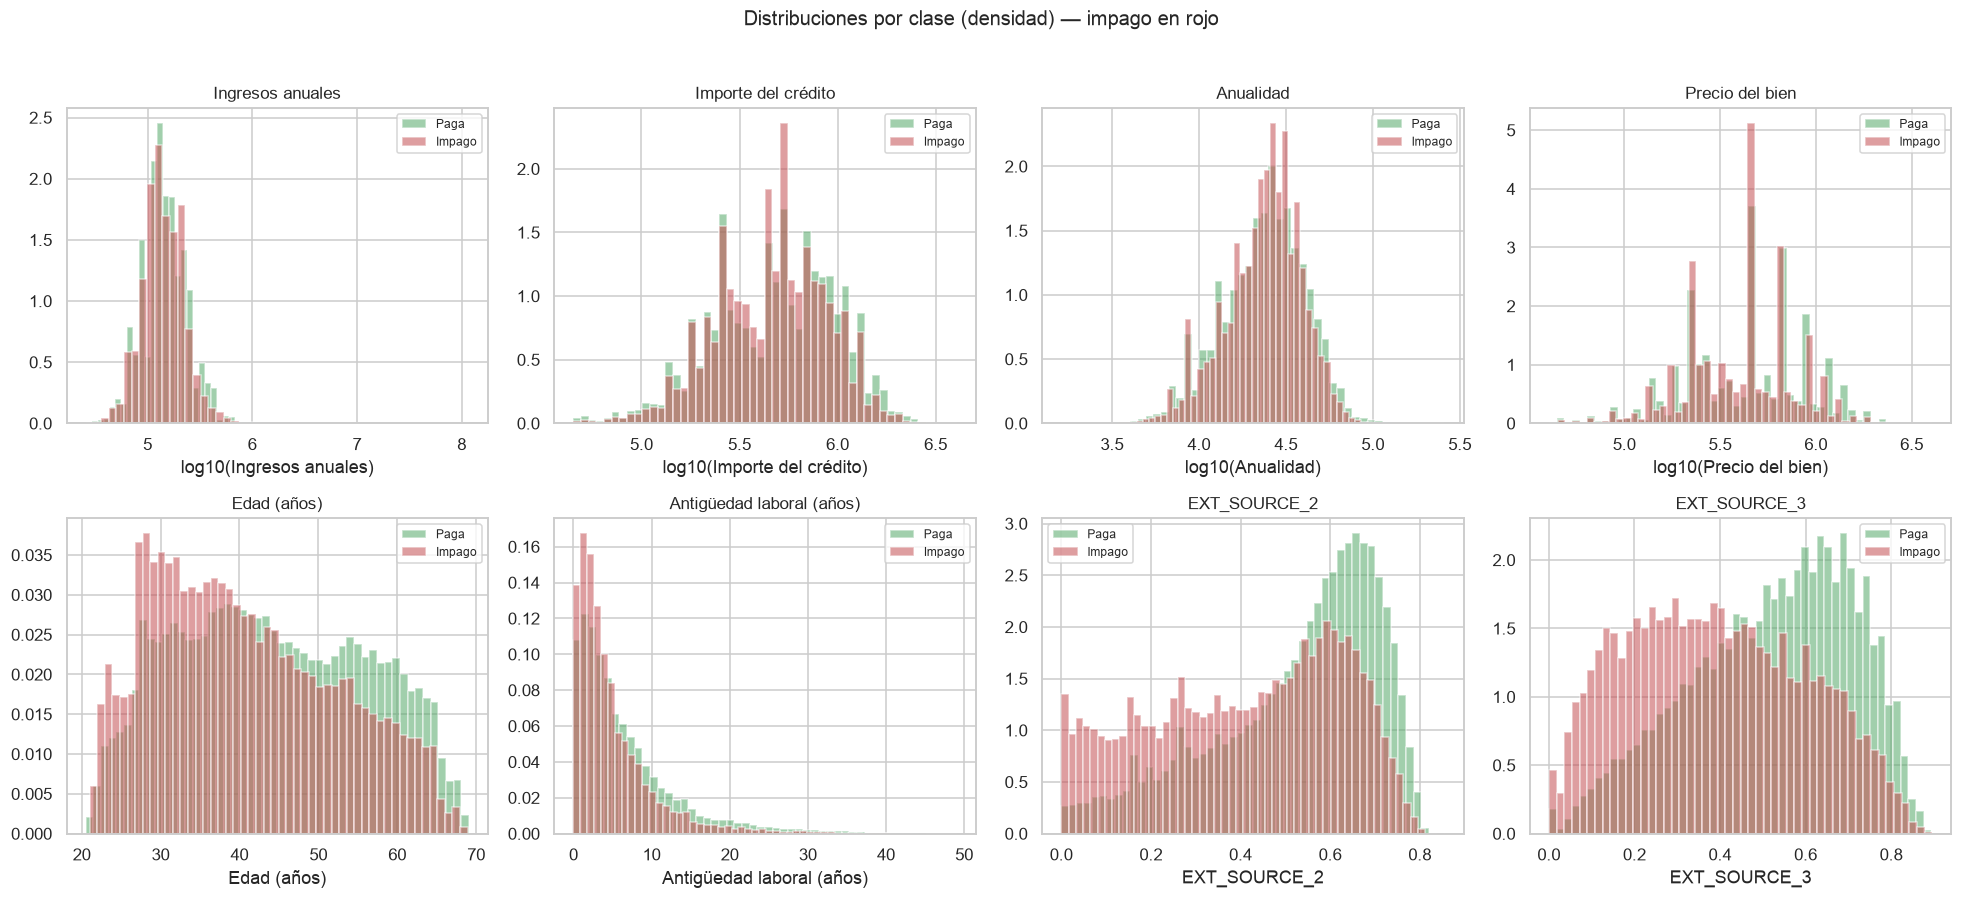

In [7]:
specs = [
    ('AMT_INCOME_TOTAL', True,  'Ingresos anuales'),
    ('AMT_CREDIT',       True,  'Importe del crédito'),
    ('AMT_ANNUITY',      True,  'Anualidad'),
    ('AMT_GOODS_PRICE',  True,  'Precio del bien'),
    ('AGE_YEARS',        False, 'Edad (años)'),
    ('EMPLOY_YEARS',     False, 'Antigüedad laboral (años)'),
    ('EXT_SOURCE_2',     False, 'EXT_SOURCE_2'),
    ('EXT_SOURCE_3',     False, 'EXT_SOURCE_3'),
]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, (col, logx, title) in zip(axes.ravel(), specs):
    for t, c, lab in [(0, C['good'], 'Paga'), (1, C['bad'], 'Impago')]:
        v = df.loc[df['TARGET']==t, col].dropna()
        if logx:
            v = v[v > 0]
            ax.hist(np.log10(v), bins=50, density=True, alpha=0.55, color=c, label=lab)
            ax.set_xlabel(f"log10({title})")
        else:
            ax.hist(v, bins=50, density=True, alpha=0.55, color=c, label=lab)
            ax.set_xlabel(title)
    ax.set_title(title); ax.legend(fontsize=8)
fig.suptitle("Distribuciones por clase (densidad) — impago en rojo", y=1.02, fontsize=13)
savefig("03_distribuciones")

### 2.5 Matriz de correlación entre variables numéricas

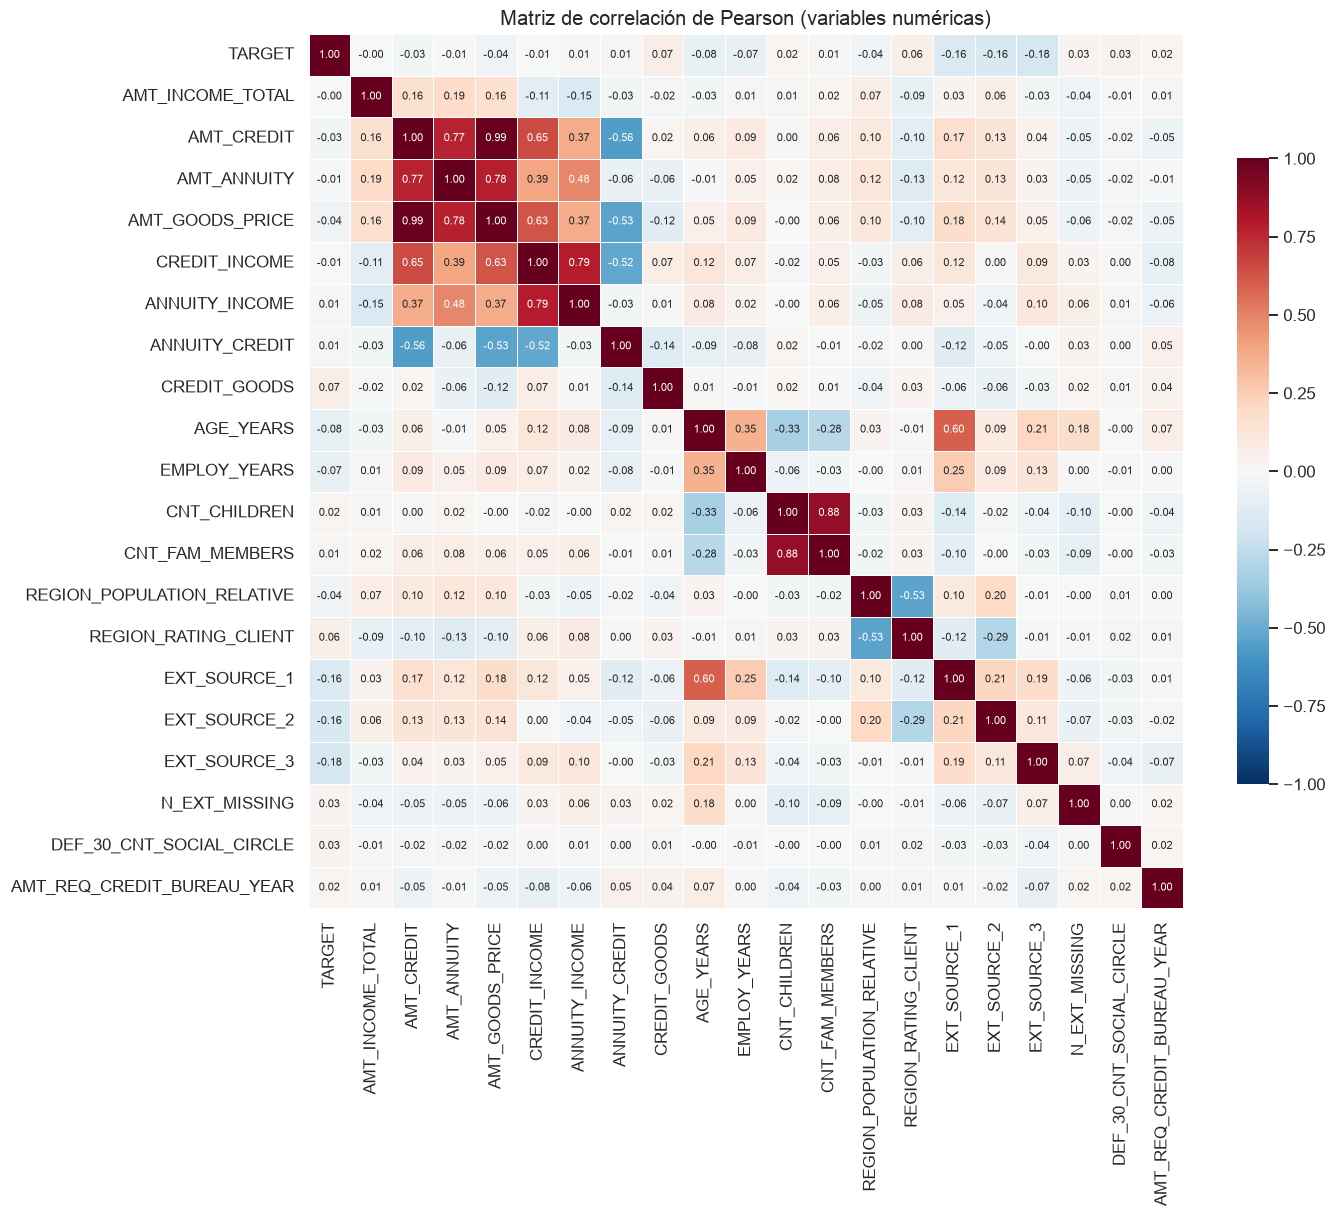

In [8]:
num = ['TARGET','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
       'CREDIT_INCOME','ANNUITY_INCOME','ANNUITY_CREDIT','CREDIT_GOODS',
       'AGE_YEARS','EMPLOY_YEARS','CNT_CHILDREN','CNT_FAM_MEMBERS',
       'REGION_POPULATION_RELATIVE','REGION_RATING_CLIENT',
       'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','N_EXT_MISSING',
       'DEF_30_CNT_SOCIAL_CIRCLE','AMT_REQ_CREDIT_BUREAU_YEAR']
corr = df[num].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':7}, square=True, linewidths=.4, cbar_kws={'shrink':.7}, ax=ax)
ax.set_title("Matriz de correlación de Pearson (variables numéricas)", fontsize=13)
savefig("04_correlacion_matriz")

### 2.6 Correlación de cada variable con `TARGET`

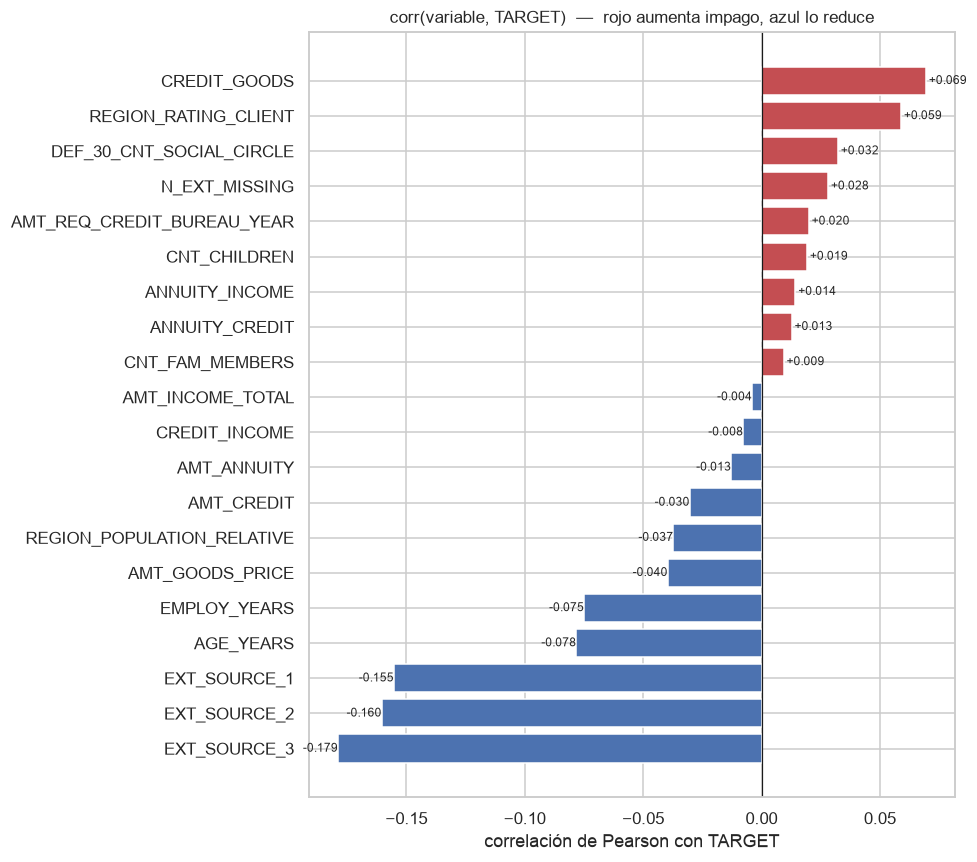

Más protectoras: ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1'] | Más de riesgo: ['DEF_30_CNT_SOCIAL_CIRCLE', 'REGION_RATING_CLIENT', 'CREDIT_GOODS']


In [9]:
ct = corr['TARGET'].drop('TARGET').sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
colors = [C['bad'] if v>0 else C['m'] for v in ct.values]
ax.barh(ct.index, ct.values, color=colors)
for i,v in enumerate(ct.values):
    ax.text(v, i, f" {v:+.3f}", va='center', ha='left' if v>=0 else 'right', fontsize=8)
ax.axvline(0, color='k', lw=.8)
ax.set_title("corr(variable, TARGET)  —  rojo aumenta impago, azul lo reduce")
ax.set_xlabel("correlación de Pearson con TARGET")
savefig("05_correlacion_target")
print("Más protectoras:", list(ct.head(3).index), "| Más de riesgo:", list(ct.tail(3).index))

### 2.7 Tasa de impago por decil (dependencias monótonas)

Para variables continuas, partimos en deciles y miramos la tasa de impago en cada uno.
Si la curva sube/baja de forma monótona, hay una **dependencia fuerte y explotable**.

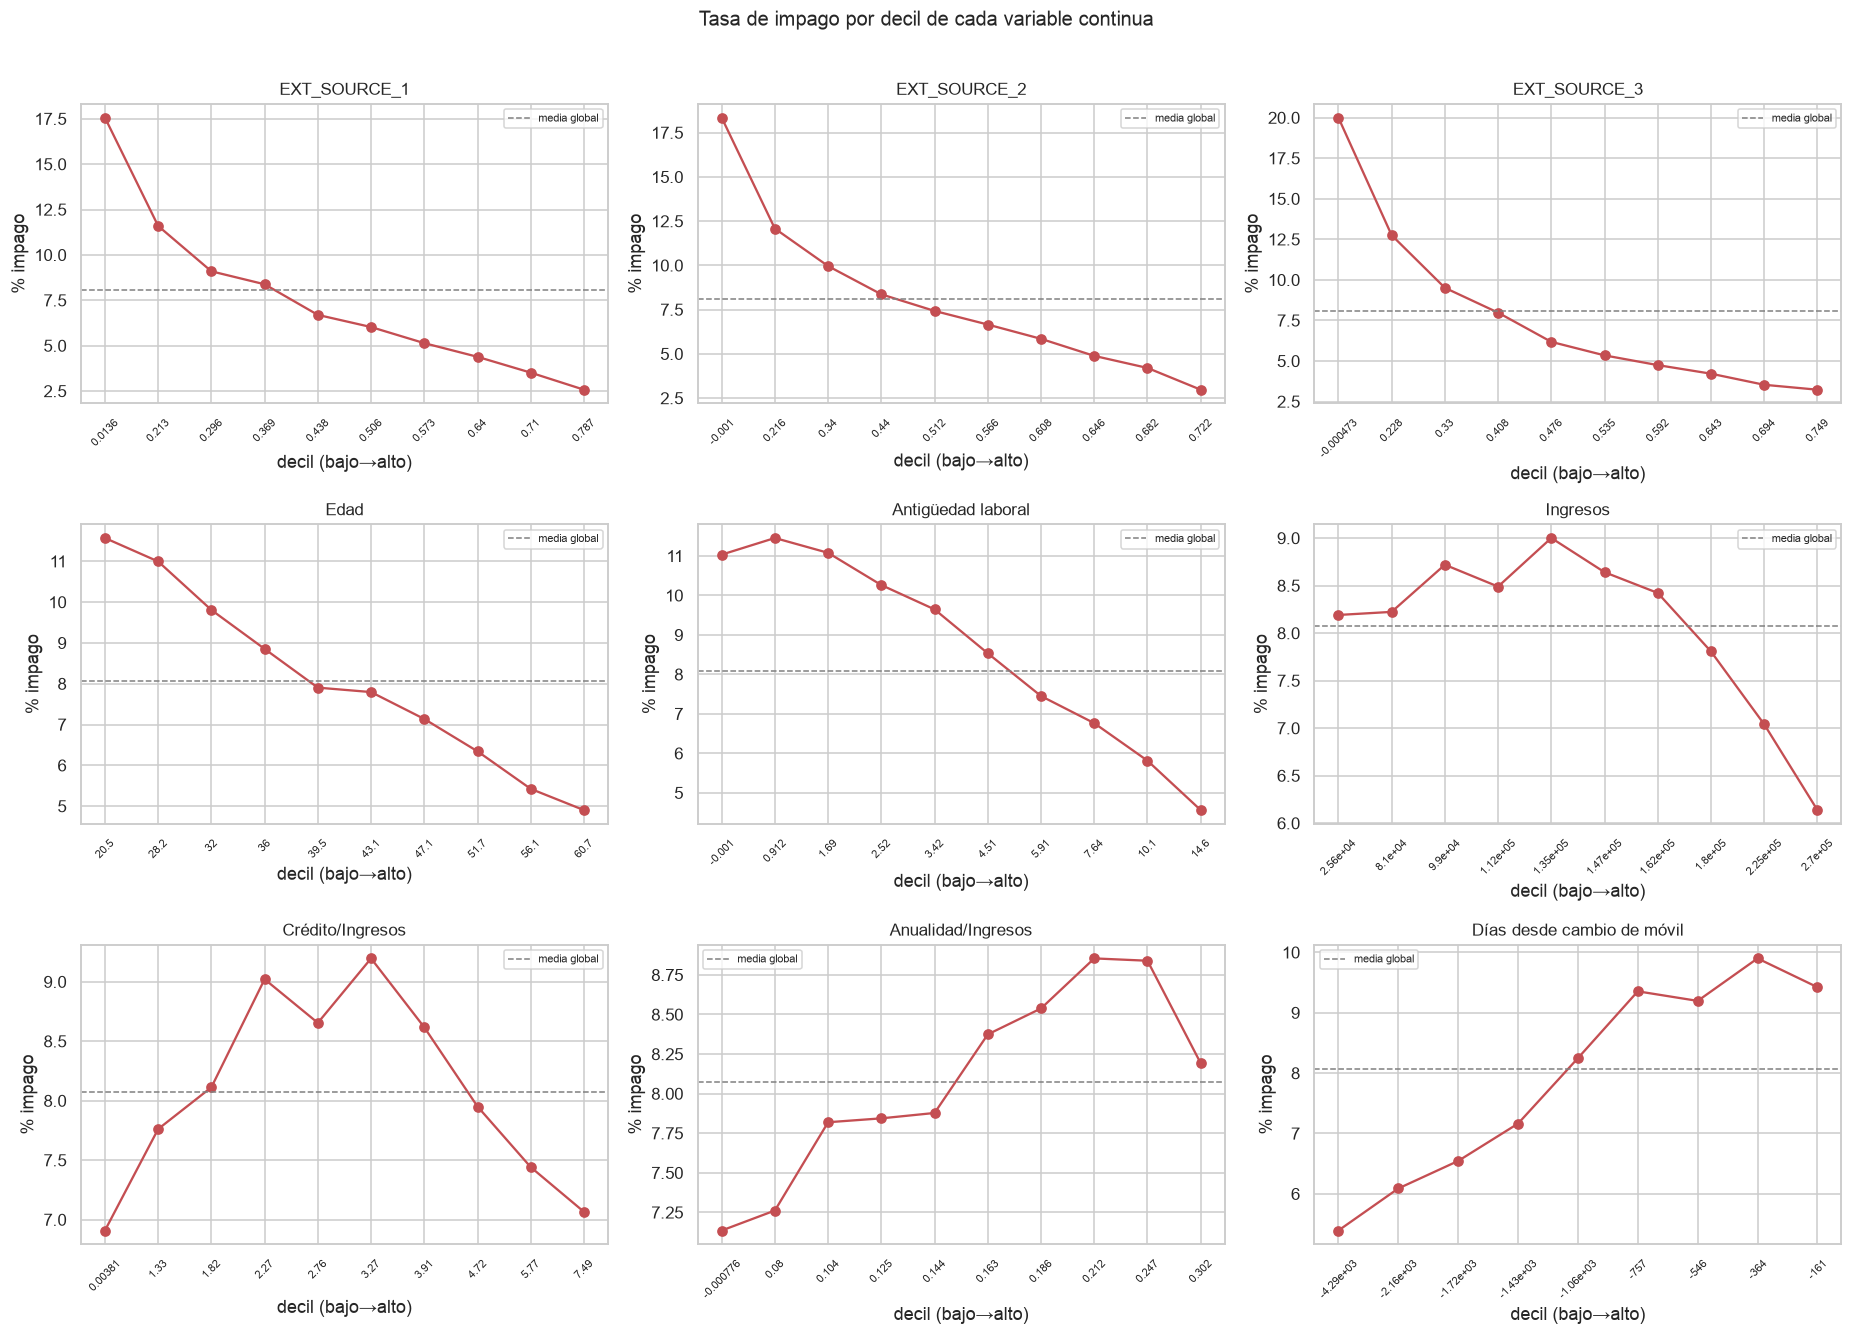

In [10]:
conts = [('EXT_SOURCE_1','EXT_SOURCE_1'), ('EXT_SOURCE_2','EXT_SOURCE_2'),
         ('EXT_SOURCE_3','EXT_SOURCE_3'), ('AGE_YEARS','Edad'),
         ('EMPLOY_YEARS','Antigüedad laboral'), ('AMT_INCOME_TOTAL','Ingresos'),
         ('CREDIT_INCOME','Crédito/Ingresos'), ('ANNUITY_INCOME','Anualidad/Ingresos'),
         ('DAYS_LAST_PHONE_CHANGE','Días desde cambio de móvil')]
fig, axes = plt.subplots(3, 3, figsize=(17, 12))
for ax, (col, title) in zip(axes.ravel(), conts):
    g = decile_default(df[col], df['TARGET'], q=10)
    ax.plot(range(len(g)), g['mean'].values*100, 'o-', color=C['bad'])
    ax.axhline(GLOBAL_DR*100, color='gray', ls='--', lw=1, label='media global')
    ax.set_title(f"{title}"); ax.set_xlabel("decil (bajo→alto)"); ax.set_ylabel("% impago")
    ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=45, fontsize=7)
    ax.legend(fontsize=7)
fig.suptitle("Tasa de impago por decil de cada variable continua", y=1.01, fontsize=13)
savefig("06_impago_por_decil")

### 2.8 Tasa de impago por categoría (variables cualitativas)

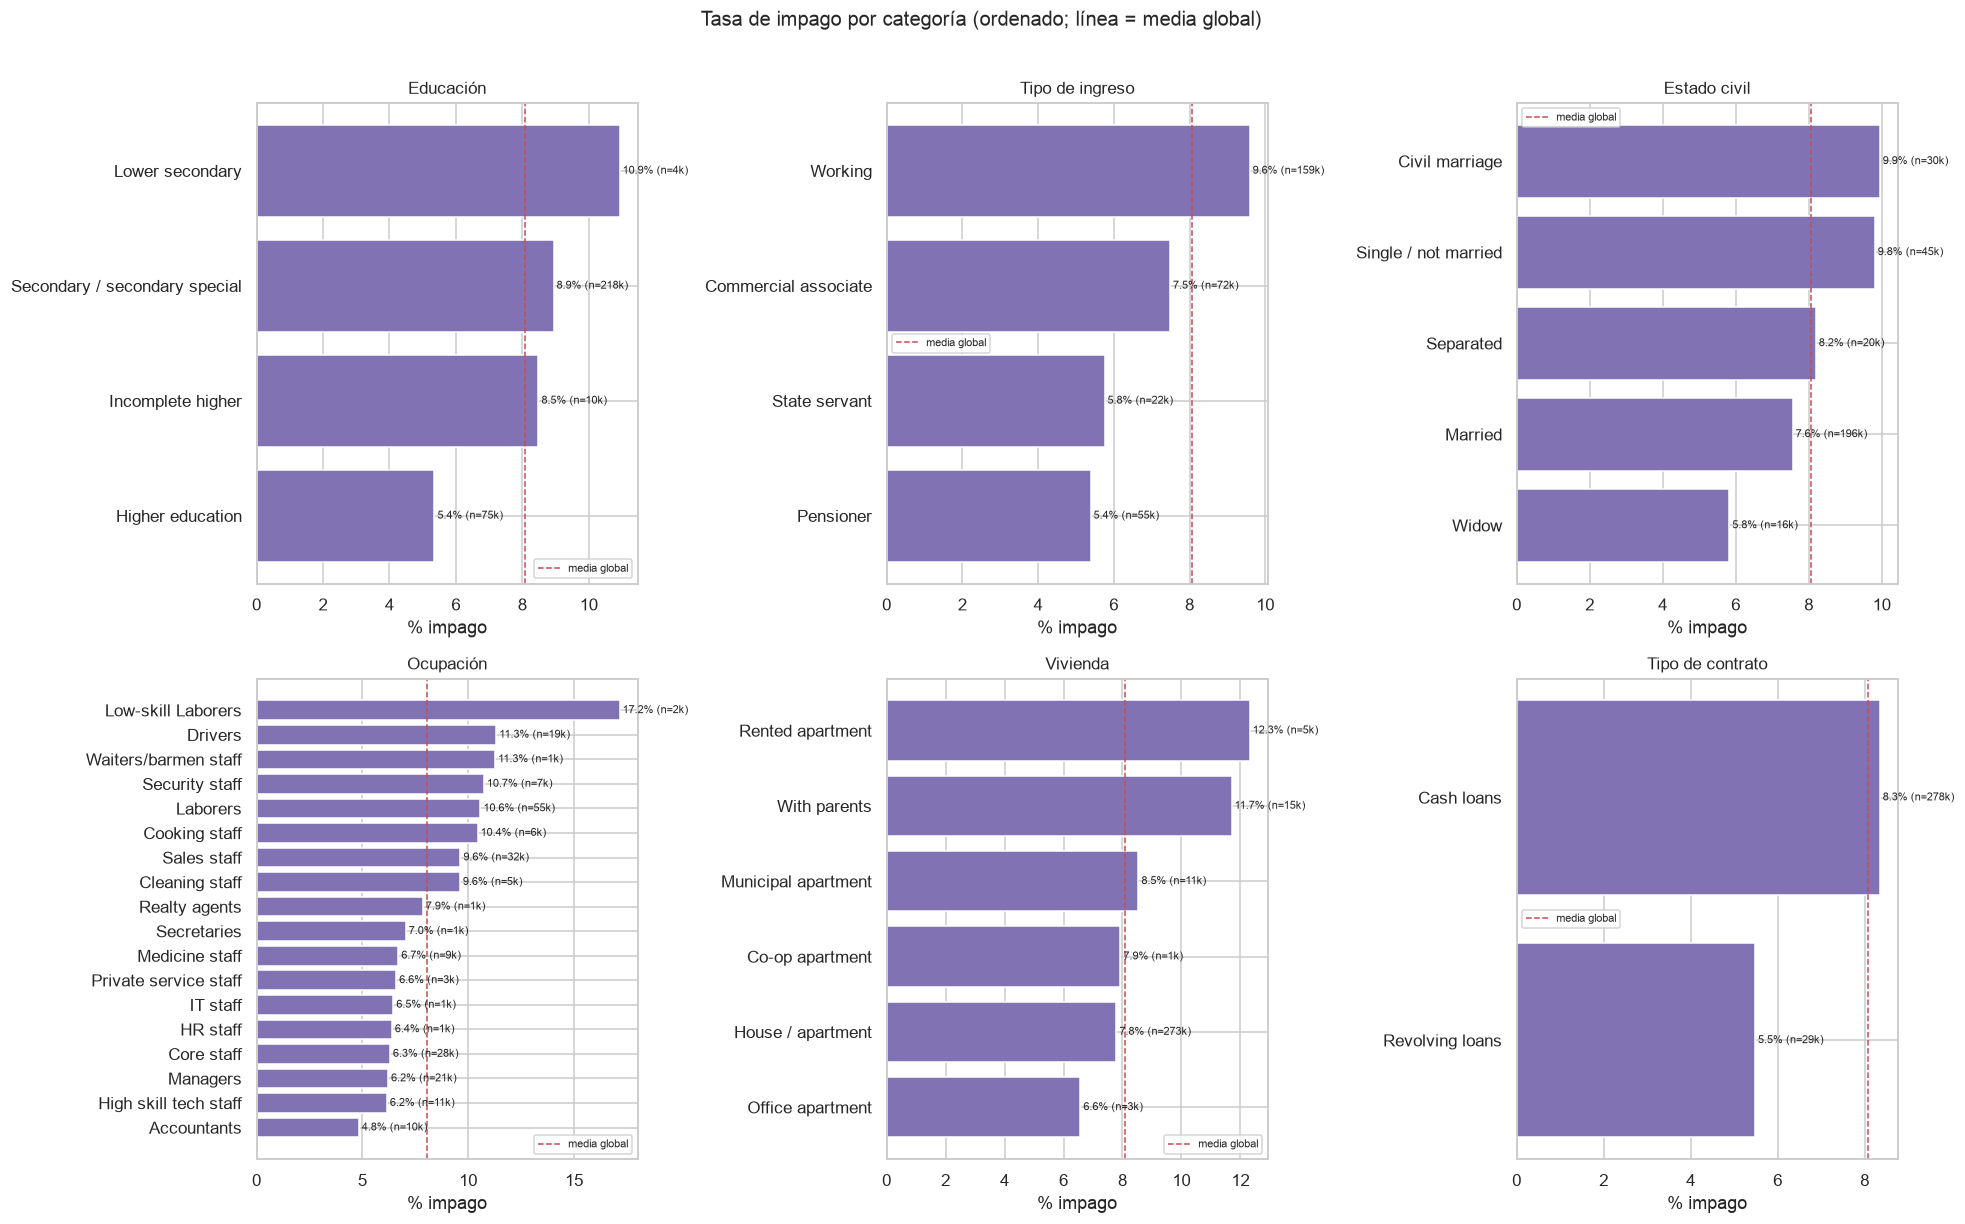

In [11]:
cats = [('NAME_EDUCATION_TYPE','Educación'), ('NAME_INCOME_TYPE','Tipo de ingreso'),
        ('NAME_FAMILY_STATUS','Estado civil'), ('OCCUPATION_TYPE','Ocupación'),
        ('NAME_HOUSING_TYPE','Vivienda'), ('NAME_CONTRACT_TYPE','Tipo de contrato')]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (col, title) in zip(axes.ravel(), cats):
    g = df.groupby(col)['TARGET'].agg(['mean','count'])
    g = g[g['count'] >= 200].sort_values('mean')
    bars = ax.barh(g.index.astype(str), g['mean'].values*100, color=C['neu'])
    for i,(m,n) in enumerate(zip(g['mean'].values, g['count'].values)):
        ax.text(m*100, i, f" {m:.1%} (n={n/1000:.0f}k)", va='center', fontsize=7)
    ax.axvline(GLOBAL_DR*100, color=C['bad'], ls='--', lw=1, label='media global')
    ax.set_title(title); ax.set_xlabel("% impago"); ax.legend(fontsize=7)
fig.suptitle("Tasa de impago por categoría (ordenado; línea = media global)", y=1.01, fontsize=13)
savefig("07_impago_por_categoria")

### 2.9 Género y variables proxy

Aunque no usemos `CODE_GENDER` como entrada, otras variables están **correladas con el
género** y actúan de *proxy*. Aquí medimos esa dependencia para entender posibles sesgos indirectos.

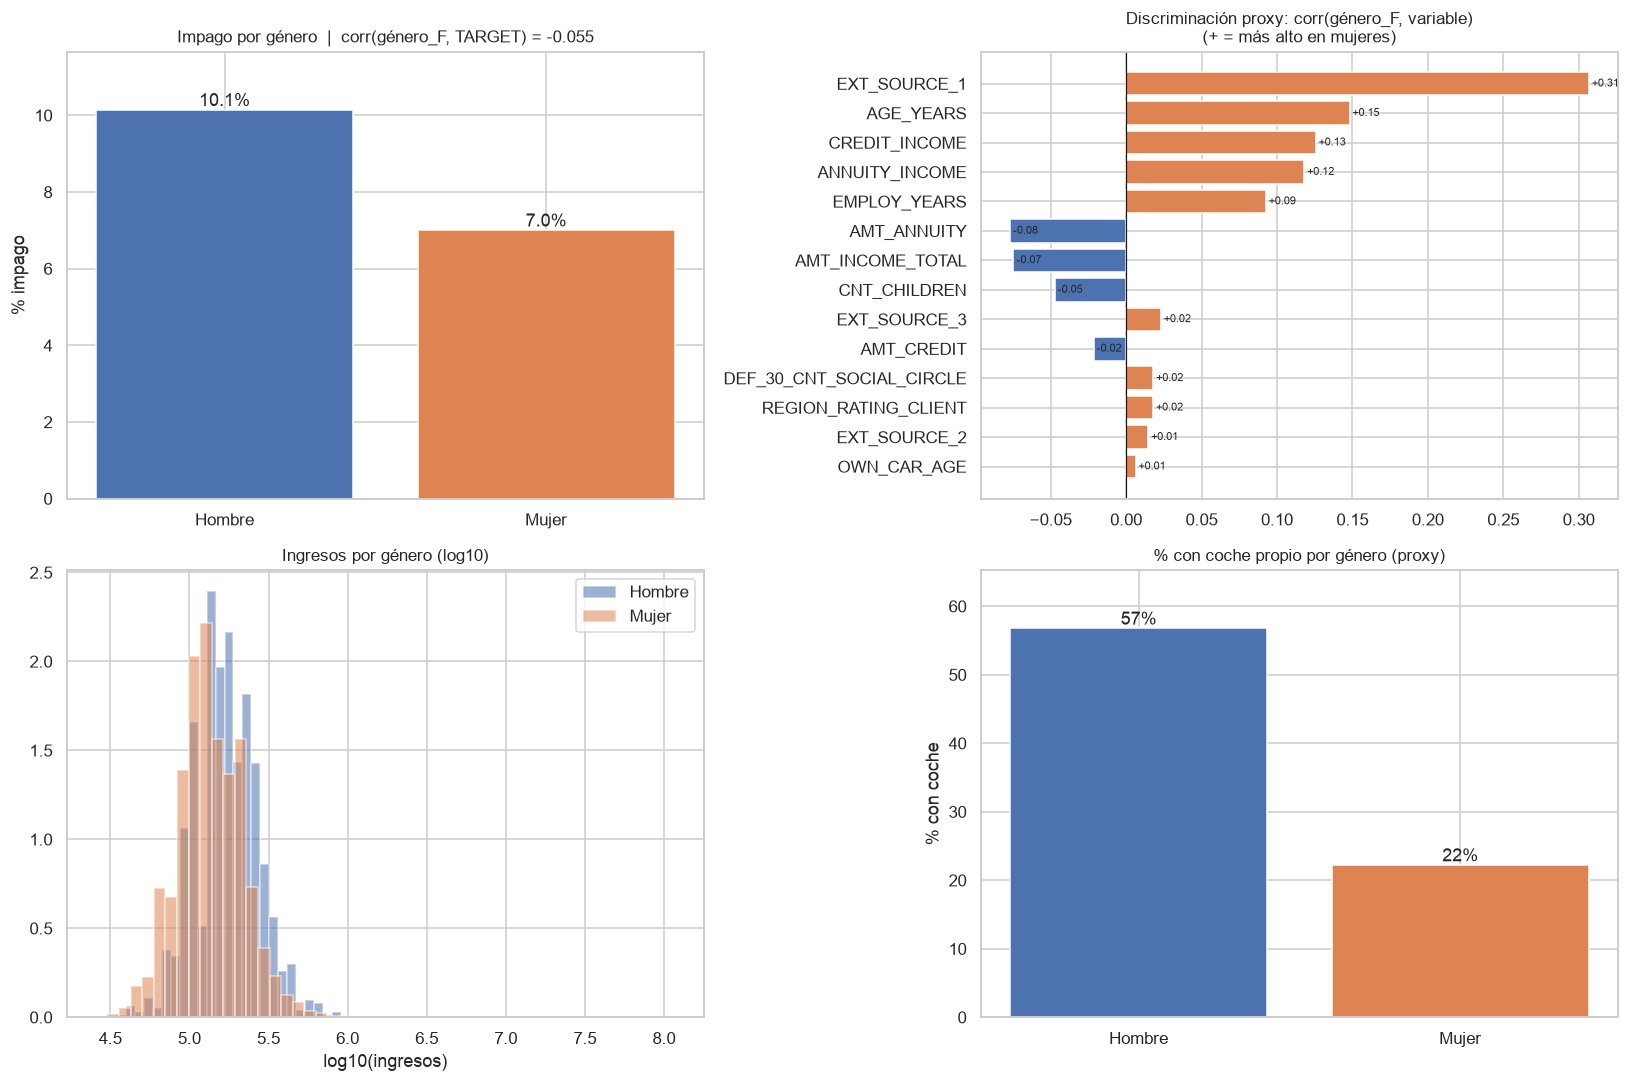

In [12]:
sub = df.dropna(subset=['GENDER_F']).copy()
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# (a) impago por género
g = sub.groupby('GENDER_F')['TARGET'].mean()
ax[0,0].bar(['Hombre','Mujer'], g.values*100, color=[C['m'], C['f']])
for i,v in enumerate(g.values): ax[0,0].text(i, v*100, f"{v:.1%}", ha='center', va='bottom')
ax[0,0].set_title(f"Impago por género  |  corr(género_F, TARGET) = {np.corrcoef(sub['GENDER_F'],sub['TARGET'])[0,1]:+.3f}")
ax[0,0].set_ylabel("% impago"); ax[0,0].margins(y=0.15)

# (b) proxy: |corr(género_F, variable numérica)|
proxy_cols = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','CREDIT_INCOME','ANNUITY_INCOME',
              'AGE_YEARS','EMPLOY_YEARS','CNT_CHILDREN','OWN_CAR_AGE','EXT_SOURCE_1',
              'EXT_SOURCE_2','EXT_SOURCE_3','REGION_RATING_CLIENT','DEF_30_CNT_SOCIAL_CIRCLE']
pc = sub[['GENDER_F']+proxy_cols].corr()['GENDER_F'].drop('GENDER_F')
pc = pc.reindex(pc.abs().sort_values().index)
ax[0,1].barh(pc.index, pc.values, color=[C['f'] if v>0 else C['m'] for v in pc.values])
for i,v in enumerate(pc.values): ax[0,1].text(v, i, f" {v:+.2f}", va='center', fontsize=7)
ax[0,1].axvline(0, color='k', lw=.8)
ax[0,1].set_title("Discriminación proxy: corr(género_F, variable)\n(+ = más alto en mujeres)")

# (c) distribución de ingresos por género
for gv, c, lab in [(0,C['m'],'Hombre'),(1,C['f'],'Mujer')]:
    v = sub.loc[sub['GENDER_F']==gv,'AMT_INCOME_TOTAL']; v=v[v>0]
    ax[1,0].hist(np.log10(v), bins=50, density=True, alpha=.55, color=c, label=lab)
ax[1,0].set_title("Ingresos por género (log10)"); ax[1,0].set_xlabel("log10(ingresos)"); ax[1,0].legend()

# (d) FLAG_OWN_CAR por género (otra proxy fuerte y conocida)
own = sub.assign(car=(sub['FLAG_OWN_CAR']=='Y').astype(int)).groupby('GENDER_F')['car'].mean()
ax[1,1].bar(['Hombre','Mujer'], own.values*100, color=[C['m'], C['f']])
for i,v in enumerate(own.values): ax[1,1].text(i, v*100, f"{v:.0%}", ha='center', va='bottom')
ax[1,1].set_title("% con coche propio por género (proxy)"); ax[1,1].set_ylabel("% con coche"); ax[1,1].margins(y=0.15)
savefig("08_genero_proxy")

### 2.10 `EXT_SOURCE` a fondo

Las tres fuentes externas son los predictores más fuertes. Aquí vemos su correlación
mutua, su relación con el impago y cómo **cuantas más faltan, mayor es el impago** — la
motivación de medir incertidumbre cuando la calidad de la fuente es peor.

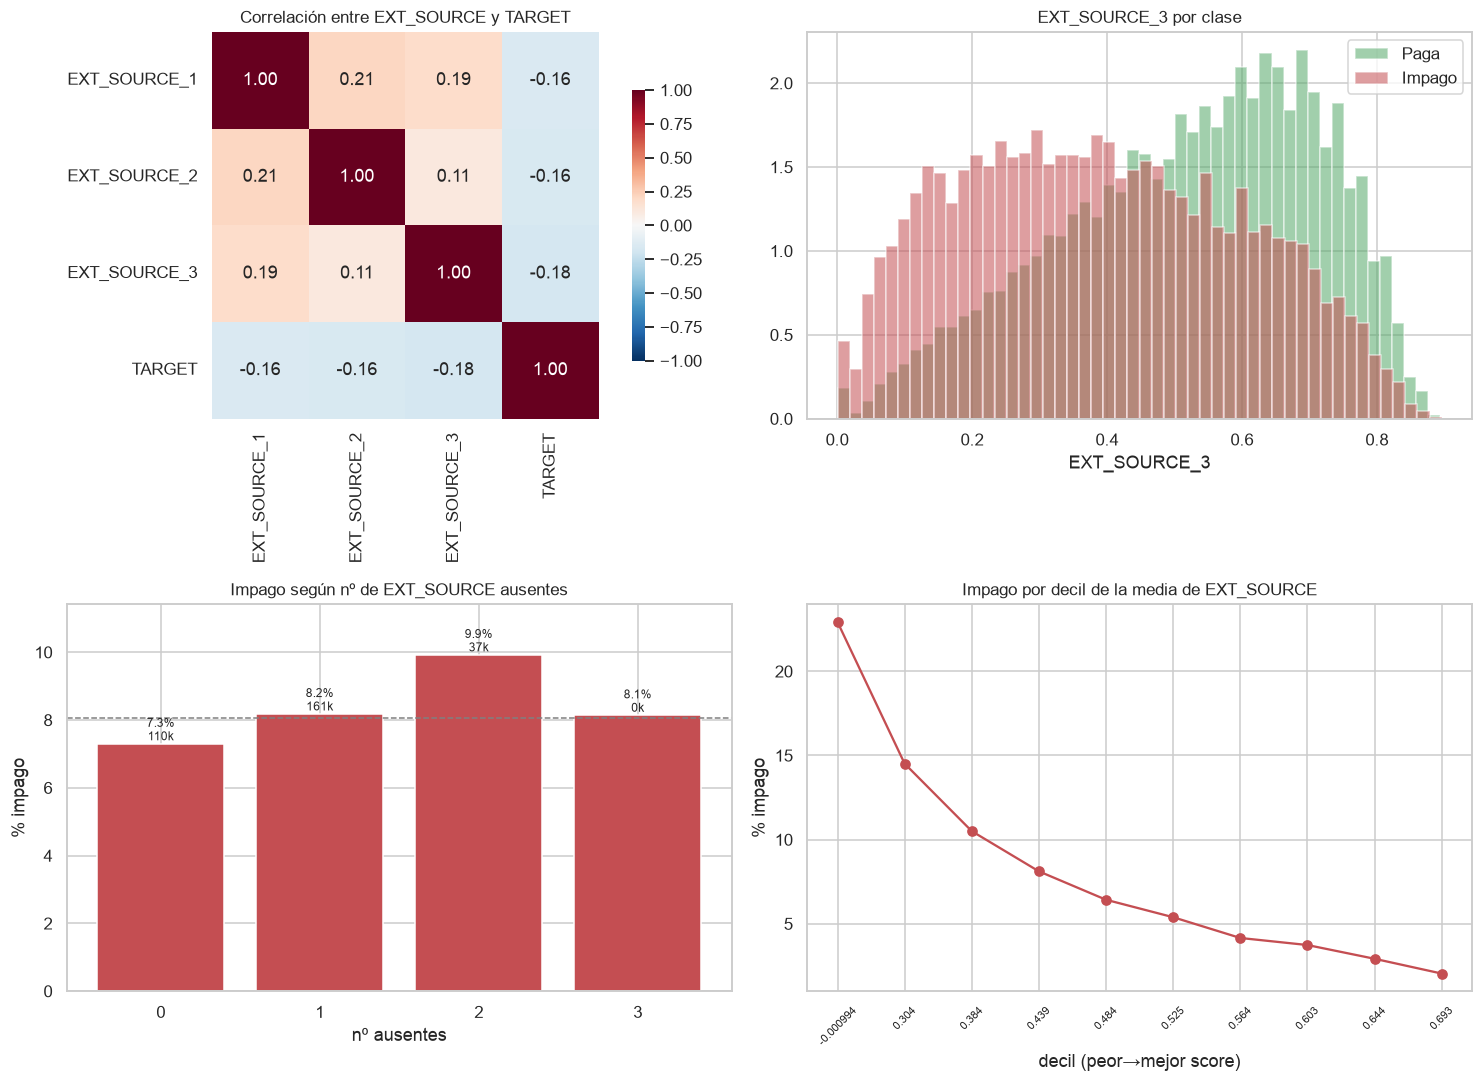

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# (a) correlación mutua de las 3 fuentes + TARGET
cc = df[EXT+['TARGET']].corr()
sns.heatmap(cc, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink':.7}, ax=ax[0,0])
ax[0,0].set_title("Correlación entre EXT_SOURCE y TARGET")

# (b) densidad de EXT_SOURCE_3 por clase
for t,c,lab in [(0,C['good'],'Paga'),(1,C['bad'],'Impago')]:
    v = df.loc[df['TARGET']==t,'EXT_SOURCE_3'].dropna()
    ax[0,1].hist(v, bins=50, density=True, alpha=.55, color=c, label=lab)
ax[0,1].set_title("EXT_SOURCE_3 por clase"); ax[0,1].set_xlabel("EXT_SOURCE_3"); ax[0,1].legend()

# (c) impago según nº de EXT_SOURCE ausentes
g = df.groupby('N_EXT_MISSING')['TARGET'].agg(['mean','count'])
ax[1,0].bar(g.index.astype(str), g['mean'].values*100, color=C['bad'])
for i,(m,n) in enumerate(zip(g['mean'],g['count'])):
    ax[1,0].text(i, m*100, f"{m:.1%}\n{n/1000:.0f}k", ha='center', va='bottom', fontsize=8)
ax[1,0].axhline(GLOBAL_DR*100, color='gray', ls='--', lw=1)
ax[1,0].set_title("Impago según nº de EXT_SOURCE ausentes"); ax[1,0].set_xlabel("nº ausentes")
ax[1,0].set_ylabel("% impago"); ax[1,0].margins(y=0.15)

# (d) media de cada fuente disponible vs impago (binned promedio EXT)
df['EXT_MEAN'] = df[EXT].mean(axis=1)
g2 = decile_default(df['EXT_MEAN'], df['TARGET'], q=10)
ax[1,1].plot(range(len(g2)), g2['mean'].values*100, 'o-', color=C['bad'])
ax[1,1].set_title("Impago por decil de la media de EXT_SOURCE")
ax[1,1].set_xlabel("decil (peor→mejor score)"); ax[1,1].set_ylabel("% impago")
ax[1,1].set_xticks(range(len(g2))); ax[1,1].set_xticklabels(g2.index, rotation=45, fontsize=7)
savefig("09_ext_source")

### 2.11 Ratios financieros de la capa custom: colas pesadas y score monotónico

`CREDIT_INCOME`, `ANNUITY_INCOME`, `ANNUITY_CREDIT` son lo que la `MonotonicDebtRiskLayer`
calcula internamente. Sus distribuciones tienen **colas muy pesadas**, lo que justifica aplicar
`log1p` y resumirlas en un score de endeudamiento monotónico.

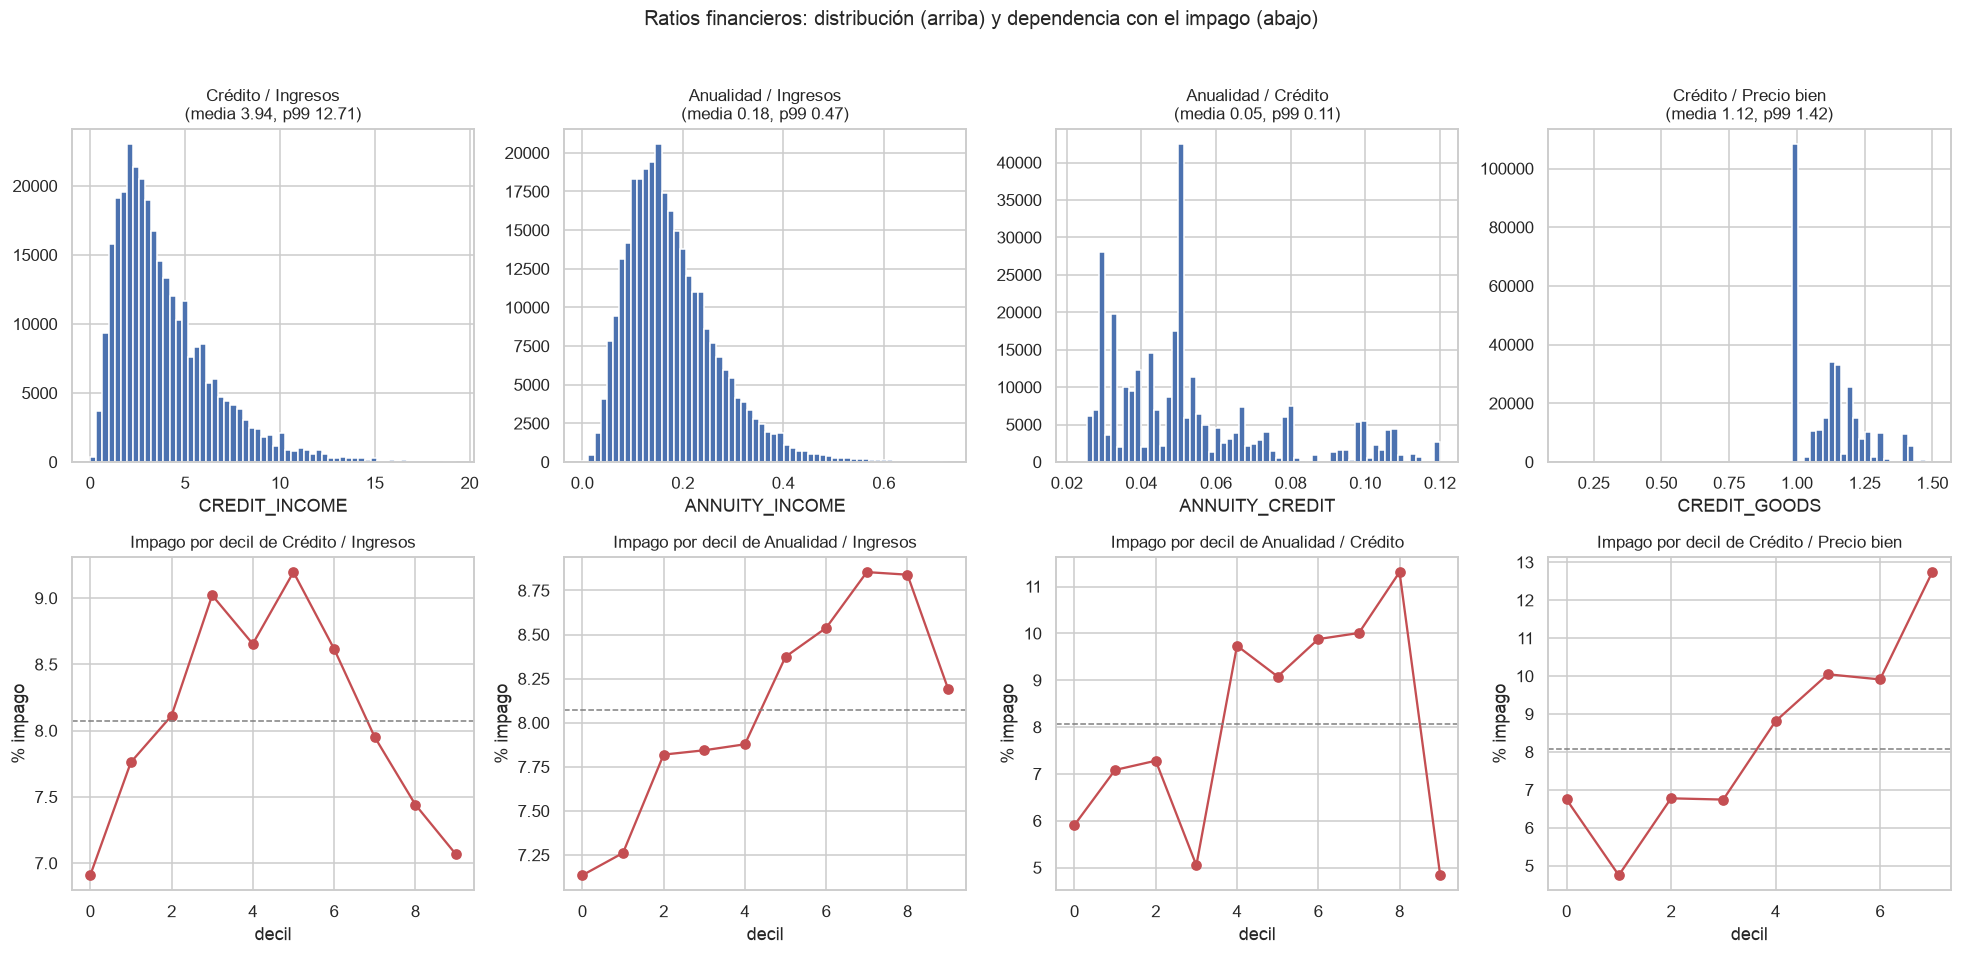

In [14]:
ratios = [('CREDIT_INCOME','Crédito / Ingresos'), ('ANNUITY_INCOME','Anualidad / Ingresos'),
          ('ANNUITY_CREDIT','Anualidad / Crédito'), ('CREDIT_GOODS','Crédito / Precio bien')]
fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
for j,(col,title) in enumerate(ratios):
    v = df[col].replace([np.inf,-np.inf], np.nan).dropna()
    v = v[(v>0) & (v < v.quantile(0.999))]
    # fila 0: histograma (cola pesada)
    axes[0,j].hist(v, bins=60, color=C['m'])
    axes[0,j].set_title(f"{title}\n(media {v.mean():.2f}, p99 {v.quantile(0.99):.2f})")
    axes[0,j].set_xlabel(col)
    # fila 1: impago por decil del ratio
    g = decile_default(df[col].replace([np.inf,-np.inf],np.nan), df['TARGET'], q=10)
    axes[1,j].plot(range(len(g)), g['mean'].values*100, 'o-', color=C['bad'])
    axes[1,j].axhline(GLOBAL_DR*100, color='gray', ls='--', lw=1)
    axes[1,j].set_title(f"Impago por decil de {title}")
    axes[1,j].set_xlabel("decil"); axes[1,j].set_ylabel("% impago")
fig.suptitle("Ratios financieros: distribución (arriba) y dependencia con el impago (abajo)",
             y=1.02, fontsize=13)
savefig("10_ratios_financieros")

### 2.12 Tabla `bureau`: historial de crédito en otras entidades

Agregamos por cliente el nº de créditos previos, la deuda total, los créditos activos y
los días de mora, y miramos su dependencia con el impago.

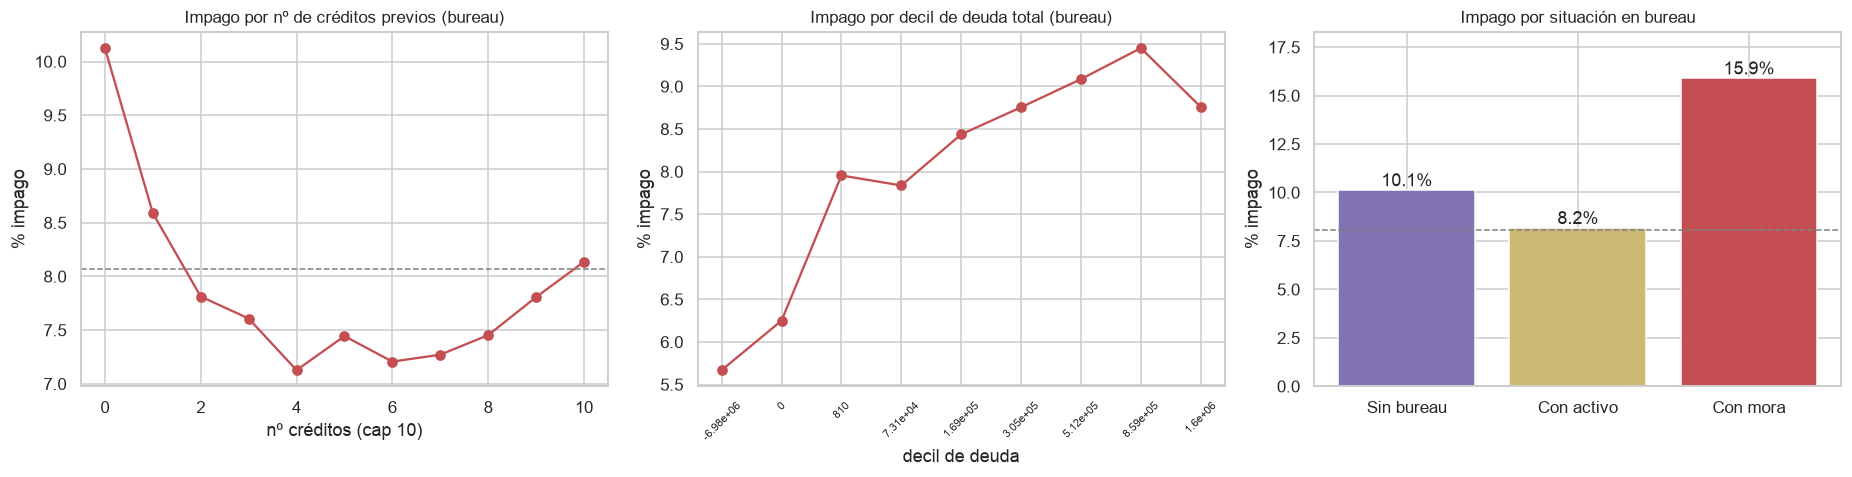

Cobertura bureau: 99% de los clientes


In [15]:
bureau = pd.read_csv(f"{DATA}/bureau.csv",
    usecols=['SK_ID_CURR','CREDIT_ACTIVE','AMT_CREDIT_SUM','AMT_CREDIT_SUM_DEBT',
             'CREDIT_DAY_OVERDUE','DAYS_CREDIT'])
agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_N=('CREDIT_ACTIVE','size'),
    BUREAU_DEBT=('AMT_CREDIT_SUM_DEBT','sum'),
    BUREAU_OVERDUE=('CREDIT_DAY_OVERDUE','max'),
    BUREAU_ACTIVE=('CREDIT_ACTIVE', lambda s: (s=='Active').sum()),
).reset_index()
b = df[['SK_ID_CURR','TARGET']].merge(agg, on='SK_ID_CURR', how='left')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
# impago por nº de créditos previos (cap a 10)
b['BN'] = b['BUREAU_N'].fillna(0).clip(upper=10)
g = b.groupby('BN')['TARGET'].mean()
ax[0].plot(g.index, g.values*100, 'o-', color=C['bad'])
ax[0].axhline(GLOBAL_DR*100, color='gray', ls='--', lw=1)
ax[0].set_title("Impago por nº de créditos previos (bureau)"); ax[0].set_xlabel("nº créditos (cap 10)")
ax[0].set_ylabel("% impago")
# impago por decil de deuda
g2 = decile_default(b['BUREAU_DEBT'], b['TARGET'], q=10)
ax[1].plot(range(len(g2)), g2['mean'].values*100, 'o-', color=C['bad'])
ax[1].set_title("Impago por decil de deuda total (bureau)"); ax[1].set_xlabel("decil de deuda")
ax[1].set_ylabel("% impago"); ax[1].set_xticks(range(len(g2))); ax[1].set_xticklabels(g2.index, rotation=45, fontsize=7)
# impago según si tiene crédito activo / con mora
b['has_active'] = (b['BUREAU_ACTIVE'].fillna(0)>0).astype(int)
b['has_overdue'] = (b['BUREAU_OVERDUE'].fillna(0)>0).astype(int)
cmp = pd.DataFrame({
    'Sin bureau': [b.loc[b['BUREAU_N'].isna(),'TARGET'].mean()],
    'Con activo': [b.loc[b['has_active']==1,'TARGET'].mean()],
    'Con mora':   [b.loc[b['has_overdue']==1,'TARGET'].mean()],
}).T[0]
ax[2].bar(cmp.index, cmp.values*100, color=[C['neu'],C['acc'],C['bad']])
for i,v in enumerate(cmp.values): ax[2].text(i, v*100, f"{v:.1%}", ha='center', va='bottom')
ax[2].axhline(GLOBAL_DR*100, color='gray', ls='--', lw=1)
ax[2].set_title("Impago por situación en bureau"); ax[2].set_ylabel("% impago"); ax[2].margins(y=0.15)
savefig("11_bureau")
print("Cobertura bureau:", f"{agg['SK_ID_CURR'].nunique()/df['SK_ID_CURR'].nunique():.0%} de los clientes")

### 2.13 Tabla `previous_application`: solicitudes previas en Home Credit

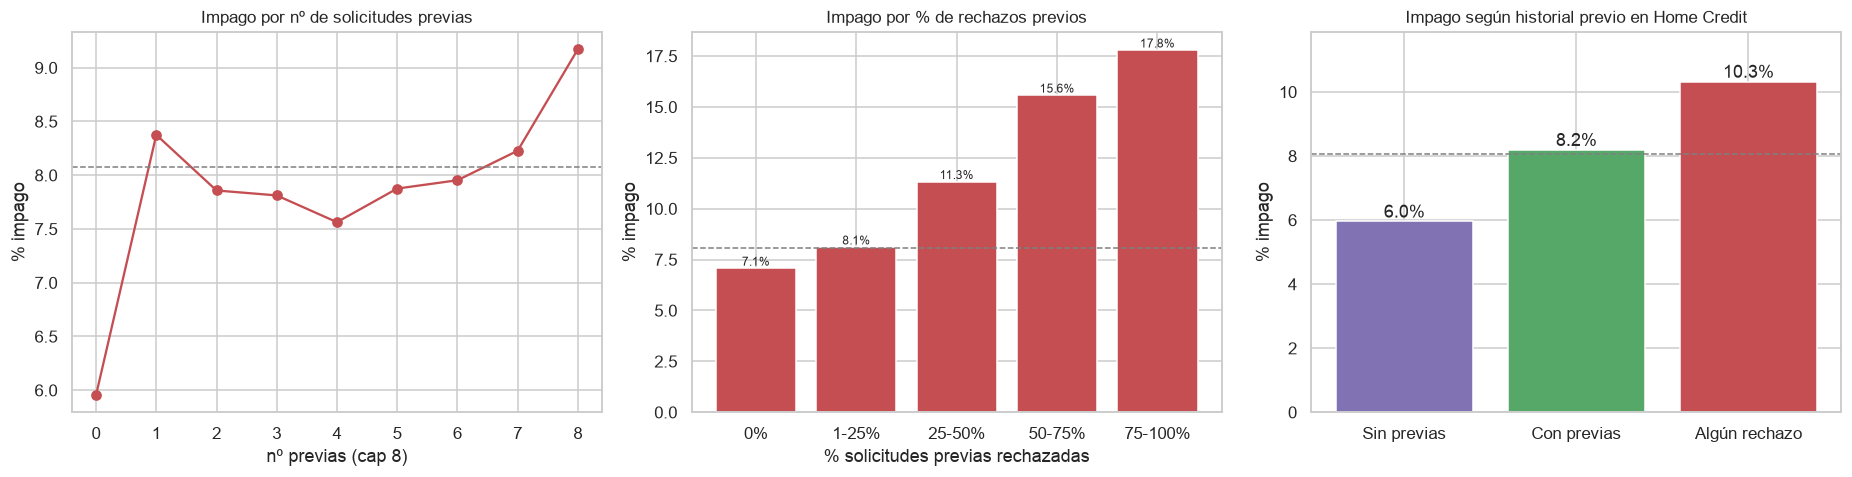

In [16]:
prev = pd.read_csv(f"{DATA}/previous_application.csv",
    usecols=['SK_ID_CURR','NAME_CONTRACT_STATUS','AMT_CREDIT','AMT_APPLICATION'])
pa = prev.groupby('SK_ID_CURR').agg(
    PREV_N=('NAME_CONTRACT_STATUS','size'),
    PREV_REFUSED=('NAME_CONTRACT_STATUS', lambda s:(s=='Refused').sum()),
    PREV_APPROVED=('NAME_CONTRACT_STATUS', lambda s:(s=='Approved').sum()),
).reset_index()
pa['PREV_REFUSE_RATE'] = pa['PREV_REFUSED'] / pa['PREV_N']
p = df[['SK_ID_CURR','TARGET']].merge(pa, on='SK_ID_CURR', how='left')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
p['PN'] = p['PREV_N'].fillna(0).clip(upper=8)
g = p.groupby('PN')['TARGET'].mean()
ax[0].plot(g.index, g.values*100, 'o-', color=C['bad'])
ax[0].axhline(GLOBAL_DR*100, color='gray', ls='--', lw=1)
ax[0].set_title("Impago por nº de solicitudes previas"); ax[0].set_xlabel("nº previas (cap 8)"); ax[0].set_ylabel("% impago")

# impago por % de rechazos previos (bins)
p['rr_bin'] = pd.cut(p['PREV_REFUSE_RATE'], [-.01,0,.25,.5,.75,1.0],
                     labels=['0%','1-25%','25-50%','50-75%','75-100%'])
g2 = p.groupby('rr_bin')['TARGET'].mean()
ax[1].bar(g2.index.astype(str), g2.values*100, color=C['bad'])
ax[1].axhline(GLOBAL_DR*100, color='gray', ls='--', lw=1)
for i,v in enumerate(g2.values): ax[1].text(i, v*100, f"{v:.1%}", ha='center', va='bottom', fontsize=8)
ax[1].set_title("Impago por % de rechazos previos"); ax[1].set_xlabel("% solicitudes previas rechazadas"); ax[1].set_ylabel("% impago")

# con/sin historial previo
cmp = pd.Series({
    'Sin previas': p.loc[p['PREV_N'].isna(),'TARGET'].mean(),
    'Con previas': p.loc[p['PREV_N'].notna(),'TARGET'].mean(),
    'Algún rechazo': p.loc[p['PREV_REFUSED'].fillna(0)>0,'TARGET'].mean(),
})
ax[2].bar(cmp.index, cmp.values*100, color=[C['neu'],C['good'],C['bad']])
for i,v in enumerate(cmp.values): ax[2].text(i, v*100, f"{v:.1%}", ha='center', va='bottom')
ax[2].axhline(GLOBAL_DR*100, color='gray', ls='--', lw=1)
ax[2].set_title("Impago según historial previo en Home Credit"); ax[2].set_ylabel("% impago"); ax[2].margins(y=0.15)
savefig("12_previous_application")

### 2.14 Comportamiento de pago: `installments_payments` y `POS_CASH_balance`

Señales de comportamiento real: **retraso de pago** (días) e **impago parcial** (pagó menos
de lo debido) de las cuotas, y los **días en mora** (`SK_DPD`) en los créditos POS/cash.
Estas son tablas grandes (10–13M filas); cargamos solo las columnas necesarias.

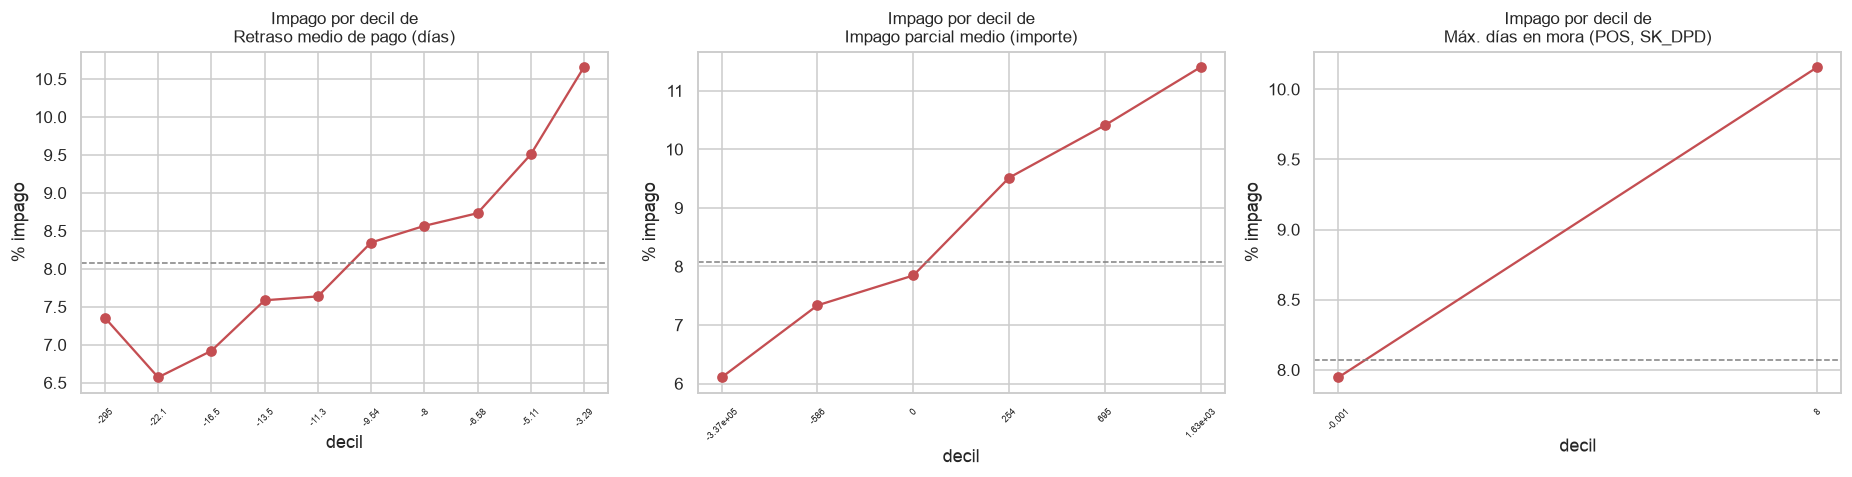

Cobertura installments: 110%


In [17]:
inst = pd.read_csv(f"{DATA}/installments_payments.csv",
    usecols=['SK_ID_CURR','DAYS_INSTALMENT','DAYS_ENTRY_PAYMENT','AMT_INSTALMENT','AMT_PAYMENT'])
inst['DELAY'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']   # >0 = pagó tarde
inst['UNDERPAY'] = inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT']        # >0 = pagó de menos
ia = inst.groupby('SK_ID_CURR').agg(
    DELAY_MEAN=('DELAY','mean'), DELAY_MAX=('DELAY','max'),
    UNDERPAY_MEAN=('UNDERPAY','mean')).reset_index()
del inst

pos = pd.read_csv(f"{DATA}/POS_CASH_balance.csv", usecols=['SK_ID_CURR','SK_DPD'])
poa = pos.groupby('SK_ID_CURR').agg(DPD_MEAN=('SK_DPD','mean'), DPD_MAX=('SK_DPD','max')).reset_index()
del pos

m = df[['SK_ID_CURR','TARGET']].merge(ia, on='SK_ID_CURR', how='left').merge(poa, on='SK_ID_CURR', how='left')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for axi,(col,title) in zip(ax, [('DELAY_MEAN','Retraso medio de pago (días)'),
                                ('UNDERPAY_MEAN','Impago parcial medio (importe)'),
                                ('DPD_MAX','Máx. días en mora (POS, SK_DPD)')]):
    g = decile_default(m[col], m['TARGET'], q=10)
    axi.plot(range(len(g)), g['mean'].values*100, 'o-', color=C['bad'])
    axi.axhline(GLOBAL_DR*100, color='gray', ls='--', lw=1)
    axi.set_title(f"Impago por decil de\n{title}"); axi.set_xlabel("decil"); axi.set_ylabel("% impago")
    axi.set_xticks(range(len(g))); axi.set_xticklabels(g.index, rotation=45, fontsize=6)
savefig("13_comportamiento_pago")
print("Cobertura installments:", f"{ia['SK_ID_CURR'].nunique()/df['SK_ID_CURR'].nunique():.0%}")

### 2.15 Síntesis — ranking de dependencias con `TARGET`

Combinamos en una sola figura la **fuerza de dependencia** con el impago de variables
numéricas (|correlación de Pearson|) y categóricas (**V de Cramér**), más las señales
agregadas de las tablas auxiliares. Es el resumen que justifica qué entra al modelo.

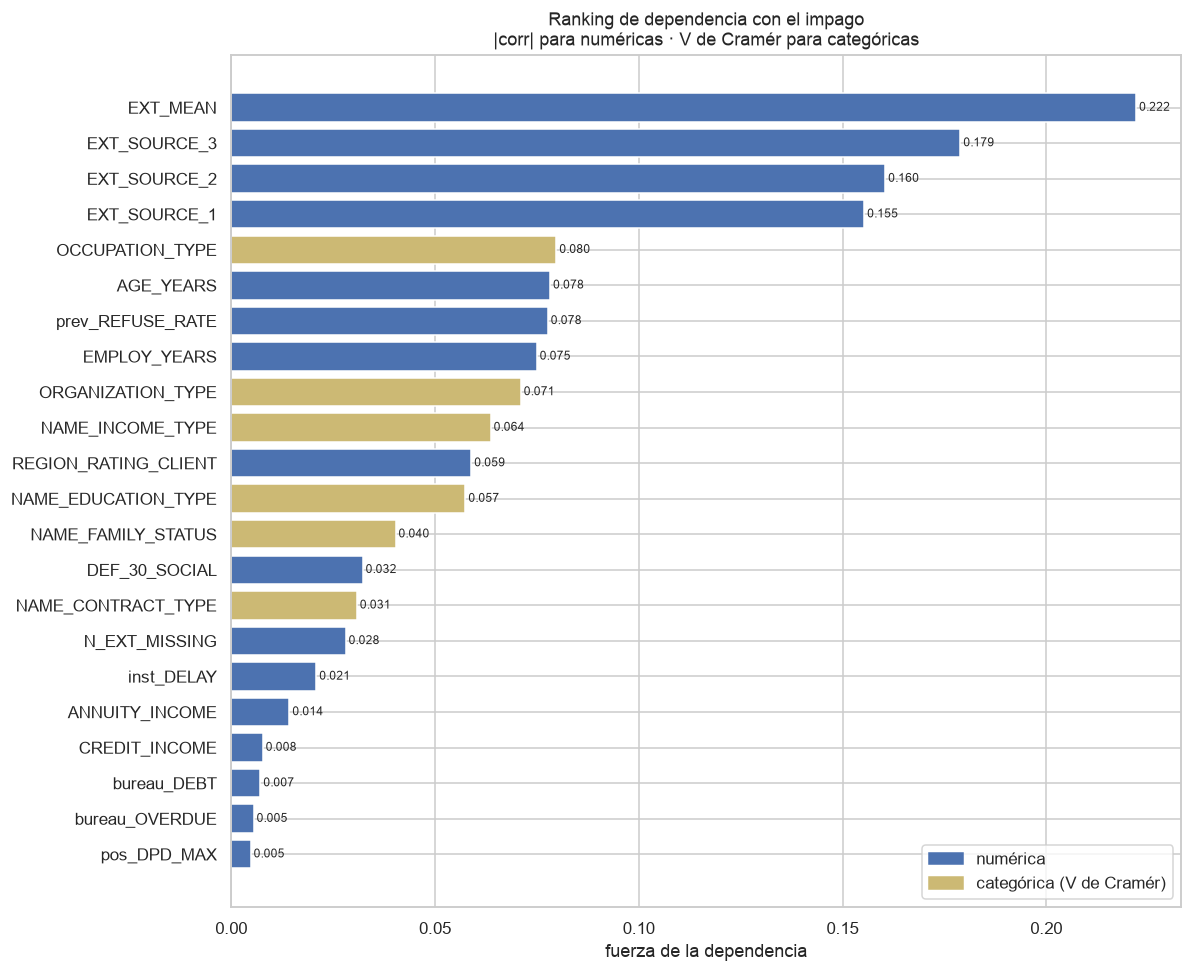

             feature  strength                     tipo
            EXT_MEAN  0.222052                 numérica
        EXT_SOURCE_3  0.178919                 numérica
        EXT_SOURCE_2  0.160472                 numérica
        EXT_SOURCE_1  0.155317                 numérica
     OCCUPATION_TYPE  0.079776 categórica (V de Cramér)
           AGE_YEARS  0.078239                 numérica
    prev_REFUSE_RATE  0.077671                 numérica
        EMPLOY_YEARS  0.074958                 numérica
   ORGANIZATION_TYPE  0.071048 categórica (V de Cramér)
    NAME_INCOME_TYPE  0.063667 categórica (V de Cramér)
REGION_RATING_CLIENT  0.058899                 numérica
 NAME_EDUCATION_TYPE  0.057458 categórica (V de Cramér)
  NAME_FAMILY_STATUS  0.040311 categórica (V de Cramér)
       DEF_30_SOCIAL  0.032248                 numérica
  NAME_CONTRACT_TYPE  0.030823 categórica (V de Cramér)
       N_EXT_MISSING  0.028071                 numérica
          inst_DELAY  0.020870                 n

In [18]:
# numéricas (incluye señales auxiliares ya fusionadas)
aux = (df[['SK_ID_CURR','TARGET']]
       .merge(agg, on='SK_ID_CURR', how='left')
       .merge(pa[['SK_ID_CURR','PREV_REFUSE_RATE','PREV_N']], on='SK_ID_CURR', how='left')
       .merge(m[['SK_ID_CURR','DELAY_MEAN','DPD_MAX']], on='SK_ID_CURR', how='left'))
num_feats = {
 'EXT_SOURCE_2':df['EXT_SOURCE_2'],'EXT_SOURCE_3':df['EXT_SOURCE_3'],'EXT_SOURCE_1':df['EXT_SOURCE_1'],
 'EXT_MEAN':df['EXT_MEAN'],'AGE_YEARS':df['AGE_YEARS'],'EMPLOY_YEARS':df['EMPLOY_YEARS'],
 'CREDIT_INCOME':df['CREDIT_INCOME'],'ANNUITY_INCOME':df['ANNUITY_INCOME'],
 'N_EXT_MISSING':df['N_EXT_MISSING'],'REGION_RATING_CLIENT':df['REGION_RATING_CLIENT'],
 'DEF_30_SOCIAL':df['DEF_30_CNT_SOCIAL_CIRCLE'],
 'bureau_DEBT':aux['BUREAU_DEBT'],'bureau_OVERDUE':aux['BUREAU_OVERDUE'],
 'prev_REFUSE_RATE':aux['PREV_REFUSE_RATE'],'inst_DELAY':aux['DELAY_MEAN'],'pos_DPD_MAX':aux['DPD_MAX'],
}
rows=[]
for name,s in num_feats.items():
    d = pd.DataFrame({'x':s.values,'y':df['TARGET'].values}).dropna()
    rows.append((name, abs(d['x'].corr(d['y'])), 'numérica'))
for col in ['NAME_EDUCATION_TYPE','NAME_INCOME_TYPE','OCCUPATION_TYPE','NAME_FAMILY_STATUS',
            'ORGANIZATION_TYPE','NAME_CONTRACT_TYPE']:
    rows.append((col, cramers_v(df[col].fillna('NA'), df['TARGET']), 'categórica (V de Cramér)'))

rank = pd.DataFrame(rows, columns=['feature','strength','tipo']).sort_values('strength')
fig, ax = plt.subplots(figsize=(11, 9))
cmap = {'numérica':C['m'], 'categórica (V de Cramér)':C['acc']}
ax.barh(rank['feature'], rank['strength'], color=[cmap[t] for t in rank['tipo']])
for i,v in enumerate(rank['strength'].values): ax.text(v, i, f" {v:.3f}", va='center', fontsize=8)
handles = [plt.Rectangle((0,0),1,1,color=cmap[k]) for k in cmap]
ax.legend(handles, cmap.keys(), loc='lower right')
ax.set_title("Ranking de dependencia con el impago\n|corr| para numéricas · V de Cramér para categóricas", fontsize=12)
ax.set_xlabel("fuerza de la dependencia")
savefig("14_ranking_dependencias")
print(rank.sort_values('strength', ascending=False).to_string(index=False))

### 2.16 Conclusiones del EDA

- **Predictores dominantes:** las tres `EXT_SOURCE` (sobre todo 2 y 3) son, con diferencia,
  lo más dependiente del impago; su **media** y el **nº de ausentes** también informan.
- **Ratios financieros** (los de la capa custom) muestran dependencia clara y **colas
  pesadas** → justifican transformar los ratios y resumirlos en un score monotónico.
- **Comportamiento histórico** (mora en bureau/POS, retrasos en cuotas, % de rechazos
  previos) aporta señal fuerte y complementaria a la foto estática.
- **Género:** correlación directa moderada con el impago, pero se **filtra vía proxies**
  (coche, ingresos, edad, nº de hijos) → conviene controlar sesgos indirectos.
- **Incertidumbre:** a más `EXT_SOURCE` ausentes, mayor impago y peor calidad de la
  predicción → coherente con derivar esos perfiles a revisión humana.

> Figuras en `outputs/eda/` (01–14). Reproducible con `data/` descargado de Kaggle.

## 3. Tarea 1 — Capa customizada: `MonotonicDebtRiskLayer`

Capa Keras escrita **solo con `keras.ops`** (backend-agnóstica). Recibe el vector
`[8 features escaladas | income, credit, annuity crudos]` y:

1. **Calcula internamente tres ratios financieros**: `crédito/ingresos`,
   `anualidad/ingresos` y `anualidad/crédito`.
2. **Transforma los ratios con `log1p`** para reducir el efecto de las colas pesadas vistas en el EDA.
3. **Aprende un score de endeudamiento monotónico** con pesos restringidos a ser positivos mediante `softplus`.
4. Devuelve `[features base | ratios log-transformados | debt_score]` para las capas densas.

La restricción matemática es interpretable: dentro de esta parte estructurada del modelo, aumentar un ratio de endeudamiento no puede disminuir el score financiero aprendido.

In [19]:
class MonotonicDebtRiskLayer(keras.layers.Layer):
    """Calcula ratios financieros y aprende un score de endeudamiento monotónico."""
    def __init__(self, n_base, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.n_base = n_base
        self.eps = eps

    def build(self, input_shape):
        # Pesos libres; softplus(raw_w) fuerza pesos estrictamente positivos en call().
        self.raw_w = self.add_weight(
            shape=(3,),
            initializer="zeros",
            trainable=True,
            name="positive_debt_weights"
        )
        self.bias = self.add_weight(
            shape=(1,),
            initializer="zeros",
            trainable=True,
            name="debt_bias"
        )
        super().build(input_shape)

    def call(self, x):
        base = x[:, :self.n_base]

        income = x[:, self.n_base:self.n_base + 1]
        credit = x[:, self.n_base + 1:self.n_base + 2]
        annuity = x[:, self.n_base + 2:self.n_base + 3]

        credit_income = credit / (income + self.eps)      # apalancamiento
        annuity_income = annuity / (income + self.eps)    # carga anual sobre ingresos
        annuity_credit = annuity / (credit + self.eps)    # intensidad de pago del crédito

        ratios = keras.ops.concatenate(
            [credit_income, annuity_income, annuity_credit],
            axis=-1
        )
        ratios = keras.ops.log1p(keras.ops.maximum(ratios, 0.0))

        positive_w = keras.ops.softplus(self.raw_w)
        debt_score = keras.ops.sum(ratios * positive_w, axis=-1, keepdims=True) + self.bias

        return keras.ops.concatenate([base, ratios, debt_score], axis=-1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.n_base + 4)

    def get_config(self):
        config = super().get_config()
        config.update({"n_base": self.n_base, "eps": self.eps})
        return config

# Smoke test: comprueba forma de salida y restricción de pesos positivos.
custom_layer = MonotonicDebtRiskLayer(N_BASE)
custom_out = custom_layer(X_train[:5])
positive_weights = keras.ops.softplus(custom_layer.raw_w)

print("Capa custom definida: MonotonicDebtRiskLayer")
print("Entrada:", X_train[:5].shape, "| salida:", custom_out.shape)
print("Salida esperada =", N_BASE, "features base + 3 ratios + 1 debt_score =", N_BASE + 4)
print("Pesos positivos iniciales:", keras.ops.convert_to_numpy(positive_weights).round(4))
assert custom_out.shape[-1] == N_BASE + 4
assert np.all(keras.ops.convert_to_numpy(positive_weights) > 0)


Capa custom definida: MonotonicDebtRiskLayer
Entrada: (5, 11) | salida: (5, 12)
Salida esperada = 8 features base + 3 ratios + 1 debt_score = 12
Pesos positivos iniciales: [0.6931 0.6931 0.6931]


## 4. Tarea 2 — Aprendizaje Justo (Fair Loss)

Objetivo: entrenar un clasificador cuyas decisiones no dependan de la variable sensible (género, `CODE_GENDER`), penalizando de forma explícita la dependencia estadística entre la predicción del modelo y dicha variable. Se construye primero el preprocesado y la función de coste customizada; sobre ella se entrenan un **modelo Base** (sin penalización) y un **modelo Fair** (con penalización), que se comparan en test.

### 4.1. Preprocesado refinado

El esqueleto de la Sección 0 es un punto de partida funcional, pero un planteamiento de aprendizaje justo y de cuantificación de incertidumbre exige varios ajustes. Cada uno se justifica a continuación.

**1. Tratamiento de registros anómalos.** La variable sensible presenta 4 registros `XNA` (género no informado) y `AMT_ANNUITY` contiene 12 valores ausentes. Se descartan estas filas (16 de 307.511, un 0,005% del total). Asignar un valor arbitrario a la variable sensible introduciría ruido directamente sobre la magnitud que la penalización de fairness pretende controlar; dado su volumen despreciable, el descarte es preferible.

**2. Flags de missingness *antes* de imputar.** Las fuentes externas presentan ausencias estructurales muy dispares: `EXT_SOURCE_1` está ausente en el 56,4% de los casos, `EXT_SOURCE_3` en el 19,8% y `EXT_SOURCE_2` en el 0,2%. Tras imputar por mediana, un valor real y uno imputado resultan indistinguibles para la red, perdiéndose la información de que el dato fue reconstruido. Se crean tres indicadores binarios (`EXT_SOURCE_k_missing`) que registran esa ausencia original. La distribución del número de fuentes imputadas por individuo —0 en el 35,6%, 1 en el 52,4%, 2 en el 11,9% y 3 en el 0,06%— define grupos de calidad de fuentes que serán el eje del análisis de incertidumbre.

**3. Imputación por mediana.** Se mantiene la imputación por mediana de las fuentes externas por su robustez frente a valores extremos. La información de ausencia queda preservada por los flags del punto anterior.

**4. Dos vistas de las variables de entrada sobre las mismas filas.** Se construyen dos conjuntos de features:
- **Base**: incluye el género como variable de entrada. Sirve de referencia y permite cuantificar la dependencia de partida.
- **Fair**: excluye el género de la entrada; la variable sensible no se proporciona al modelo y se reserva únicamente para la penalización de la loss.

Ambas vistas se derivan del **mismo** particionado, de modo que la comparación Base vs Fair se realiza sobre exactamente los mismos individuos en test.

**5. Particionado estratificado por `TARGET`.** Con una prevalencia de impago del 8%, un split aleatorio simple puede generar particiones con proporciones de clase distintas. La estratificación por `TARGET` mantiene la prevalencia (~8%) en train, validación y test, condición necesaria para que las métricas entre particiones sean comparables. Reparto 80/10/10 (mismo split que el resto del notebook).

**6. Escalado solo de variables continuas, ajustado solo con train.** El `StandardScaler` se ajusta exclusivamente con la partición de entrenamiento (evita fuga de información hacia validación y test) y se aplica únicamente sobre las variables continuas. Estandarizar variables binarias (género y flags) distorsiona su escala 0/1 sin aportar valor; se mantienen sin transformar.

**7. Sobre el efecto proxy.** Excluir el género de la entrada (vista Fair) no garantiza por sí solo un modelo justo: otras variables (ingresos, anualidad) pueden actuar como proxy y recoger información del género de forma implícita. La penalización de la Fair Loss actúa sobre la dependencia entre la predicción y el género con independencia del canal por el que esta entre. La comparativa Base vs Fair permitirá observar la dependencia residual.

In [8]:
# ---- Preprocesado refinado para Aprendizaje Justo ----
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RUTA = CSV_PATH   # misma fuente que el resto del notebook
SEED = 42

EXT_COLS  = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
FLAG_COLS = [f'{c}_missing' for c in EXT_COLS]
CONT_COLS = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH'] + EXT_COLS


def cargar_datos_fair(ruta):
    cols = ['TARGET', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
            'AMT_ANNUITY', 'DAYS_BIRTH'] + EXT_COLS
    df = pd.read_csv(ruta, usecols=cols)

    # 1. Género -> numérico (M:0, F:1). Los 4 'XNA' quedan como NaN y se descartan.
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})

    # 2. Edad: de días negativos a años positivos.
    df['DAYS_BIRTH'] = np.abs(df['DAYS_BIRTH']) / 365.0

    # 3. Flags de missingness ANTES de imputar (preservan la info de ausencia).
    for c in EXT_COLS:
        df[f'{c}_missing'] = df[c].isna().astype(int)

    # 4. Descarte de filas con sensible ambiguo (XNA) o AMT_ANNUITY ausente (16 filas).
    df = df.dropna(subset=['CODE_GENDER', 'AMT_ANNUITY']).reset_index(drop=True)
    df['CODE_GENDER'] = df['CODE_GENDER'].astype(int)

    # 5. Imputación por mediana de las fuentes externas.
    for c in EXT_COLS:
        df[c] = df[c].fillna(df[c].median())

    return df


df_fair = cargar_datos_fair(RUTA)

# Objetivo y variable sensible (esta se reserva aparte para la Fair Loss).
y = df_fair['TARGET'].values.astype('float32')
s = df_fair['CODE_GENDER'].values.astype('float32')

# Dos vistas de las features sobre las mismas filas.
feat_base = ['CODE_GENDER'] + CONT_COLS + FLAG_COLS   # incluye género
feat_fair = CONT_COLS + FLAG_COLS                     # excluye género

# Split único estratificado por TARGET (80/10/10).
idx = np.arange(len(df_fair))
idx_tr, idx_te = train_test_split(idx, test_size=0.10, random_state=SEED, stratify=y)
idx_tr, idx_va = train_test_split(idx_tr, test_size=0.10/0.90, random_state=SEED, stratify=y[idx_tr])

# Escalado: ajustado SOLO con train y SOLO sobre continuas. Binarias passthrough.
scaler = StandardScaler().fit(df_fair.loc[idx_tr, CONT_COLS])

def construir_X(indices, feats):
    bloque = df_fair.loc[indices, feats].copy()
    bloque[CONT_COLS] = scaler.transform(bloque[CONT_COLS])  # solo continuas
    return bloque.values.astype('float32')

# Matrices Base (con género) y Fair (sin género).
X_base_tr, X_base_va, X_base_te = (construir_X(i, feat_base) for i in (idx_tr, idx_va, idx_te))
X_fair_tr, X_fair_va, X_fair_te = (construir_X(i, feat_fair) for i in (idx_tr, idx_va, idx_te))

# Targets y sensible por partición.
y_tr, y_va, y_te = y[idx_tr], y[idx_va], y[idx_te]
s_tr, s_va, s_te = s[idx_tr], s[idx_va], s[idx_te]

# ---- Verificación ----
print('Filas tras limpieza:', len(df_fair))
print('Shape X_base (tr/va/te):', X_base_tr.shape, X_base_va.shape, X_base_te.shape)
print('Shape X_fair (tr/va/te):', X_fair_tr.shape, X_fair_va.shape, X_fair_te.shape)
print('\nFeatures Base:', feat_base)
print('Features Fair:', feat_fair)
print(f'\nPrevalencia TARGET  (tr/va/te): {y_tr.mean():.4f} / {y_va.mean():.4f} / {y_te.mean():.4f}')
print(f'% mujeres (s=1)     (tr/va/te): {s_tr.mean():.4f} / {s_va.mean():.4f} / {s_te.mean():.4f}')
print('Prevalencia flags EXT (train):',
      {c: round(float(df_fair.loc[idx_tr, c].mean()), 4) for c in FLAG_COLS})

Filas tras limpieza: 307495
Shape X_base (tr/va/te): (245995, 11) (30750, 11) (30750, 11)
Shape X_fair (tr/va/te): (245995, 10) (30750, 10) (30750, 10)

Features Base: ['CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing']
Features Fair: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing']

Prevalencia TARGET  (tr/va/te): 0.0807 / 0.0807 / 0.0807
% mujeres (s=1)     (tr/va/te): 0.6588 / 0.6543 / 0.6585
Prevalencia flags EXT (train): {'EXT_SOURCE_1_missing': 0.5642, 'EXT_SOURCE_2_missing': 0.0022, 'EXT_SOURCE_3_missing': 0.1982}


### 4.2. Función de coste customizada (Fair Loss)

La función de coste combina dos objetivos en un único término optimizable por descenso de gradiente:

$$\mathcal{L}(\hat{y},\, y,\, s) = \text{BCE}_w(y, \hat{y}) \;+\; \lambda \cdot \rho(\hat{y}, s)^2$$

**Término 1 — error de clasificación.** Entropía cruzada binaria entre la etiqueta real y la probabilidad predicha, ponderada por clase: cada muestra pesa $w_1$ si es impago y $w_0$ en caso contrario, con pesos inversos a la frecuencia (≈11,4× para la clase positiva). La ponderación se incorpora dentro de la loss en lugar de vía `class_weight`, por dos motivos: (i) `class_weight` no es compatible con etiquetas extendidas $[y, s]$ ni con una penalización a nivel de batch; y (ii) al aplicarse de forma idéntica en train y validación, ambas *loss* quedan en la misma escala y las curvas de convergencia resultan directamente comparables.

**Término 2 — penalización por dependencia.** Correlación de Pearson al cuadrado entre la probabilidad predicha y la variable sensible. Es derivable —a diferencia de métricas de fairness como la diferencia de paridad demográfica, no penalizables directamente por gradiente—, está acotada en $[0, 1]$ (0 = independencia lineal) y, al elevarse al cuadrado, penaliza por igual correlación positiva y negativa empujándola hacia cero. Constituye un proxy directo de paridad demográfica: si la decisión es independiente del género, la tasa de concesión se iguala entre grupos.

**Coeficiente $\lambda$.** Regula el equilibrio precisión↔justicia. Con $\lambda=0$ la penalización desaparece y la loss es BCE ponderada pura (modelo Base). Al aumentar $\lambda$ se sacrifica capacidad predictiva a cambio de menor dependencia.

**Etiquetas extendidas.** La función de coste solo recibe `y_true` e `y_pred`. Para disponer de la variable sensible dentro de la loss, se apilan la etiqueta real y el género en un tensor de dos columnas $[y, s]$ que se entrega como `y_true`.

In [ ]:
# ---- Función de coste customizada (Fair Loss) ----
import keras
from keras import ops
from sklearn.utils.class_weight import compute_class_weight

# Pesos de clase (inversos a la frecuencia) que entran DENTRO de la loss.
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr)
W0, W1 = float(cw[0]), float(cw[1])
print('Pesos de clase -> w0:', round(W0, 4), '| w1:', round(W1, 4))


class FairLoss(keras.losses.Loss):
    """BCE ponderada por clase + lambda * Pearson(y_pred, s)^2.
    y_true llega extendido como [y_real, s] (dos columnas)."""

    def __init__(self, lam=1.0, w0=1.0, w1=1.0, name='fair_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.lam, self.w0, self.w1 = lam, w0, w1

    def call(self, y_true_ext, y_pred):
        y = ops.cast(y_true_ext[:, 0], 'float32')          # etiqueta real
        s = ops.cast(y_true_ext[:, 1], 'float32')          # variable sensible
        yhat = ops.squeeze(y_pred, axis=-1) if len(y_pred.shape) > 1 else y_pred
        yhat = ops.clip(yhat, 1e-7, 1 - 1e-7)              # estabilidad del log

        # Término 1: BCE ponderada por clase (media ponderada).
        bce = -(y * ops.log(yhat) + (1 - y) * ops.log(1 - yhat))
        w = y * self.w1 + (1 - y) * self.w0
        bce_w = ops.sum(w * bce) / ops.sum(w)

        # Término 2: penalización por dependencia (Pearson^2).
        yhat_c = yhat - ops.mean(yhat)
        s_c = s - ops.mean(s)
        cov = ops.mean(yhat_c * s_c)
        den = ops.sqrt(ops.mean(ops.square(yhat_c)) * ops.mean(ops.square(s_c))) + 1e-7
        penalty = ops.square(cov / den)

        return bce_w + self.lam * penalty


# Etiquetas extendidas [y, s] por partición.
def extender(y_arr, s_arr):
    return np.stack([y_arr, s_arr], axis=1).astype('float32')

y_tr_ext = extender(y_tr, s_tr)
y_va_ext = extender(y_va, s_va)
y_te_ext = extender(y_te, s_te)
print('Shape etiquetas extendidas (train):', y_tr_ext.shape)

### 4.3. Modelo Base (Fair Loss con λ=0)

Modelo de referencia, entrenado con la Fair Loss en $\lambda=0$ (sin penalización de justicia) y sobre la vista **con género** (`X_base`, 11 variables). Cuantifica el rendimiento y la dependencia de partida sobre los que se medirá el efecto de la penalización.

Arquitectura y entrenamiento:
- **MLP 16 → 8 → 1**, capas ocultas con ReLU (gradiente estable, sin el desvanecimiento propio de la sigmoide en capas internas) y salida sigmoide para producir una probabilidad en $[0, 1]$.
- **Pesos de clase dentro de la loss** para compensar el 8% de positivos.
- **`batch_size` = 128** y **entrenamiento completo de 30 épocas** sin parada temprana, para observar la convergencia.

Se monitoriza la **accuracy** durante el entrenamiento. No obstante, con un desbalanceo del 8% la accuracy es una métrica engañosa —un clasificador que prediga siempre la clase mayoritaria alcanza ~92% sin detectar ningún impago—, por lo que la evaluación final (1.5) se apoya además en AUC-ROC y AUC-PR, independientes del umbral.

In [ ]:
# ---- Modelo Base: Fair Loss con lambda=0, vista CON género ----
EPOCHS, BATCH = 30, 128

def construir_mlp(n_inputs, nombre):
    keras.utils.set_random_seed(SEED)
    return keras.Sequential([
        keras.layers.Input(shape=(n_inputs,)),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(8,  activation='relu'),
        keras.layers.Dense(1,  activation='sigmoid')
    ], name=nombre)

# La accuracy necesita la etiqueta real, que viaja en la columna 0 del target extendido.
class AccExt(keras.metrics.BinaryAccuracy):
    def update_state(self, y_true_ext, y_pred, sample_weight=None):
        super().update_state(y_true_ext[:, 0:1], y_pred, sample_weight)

model_base = construir_mlp(X_base_tr.shape[1], 'modelo_base')
model_base.compile(optimizer='adam',
                   loss=FairLoss(lam=0.0, w0=W0, w1=W1),
                   metrics=[AccExt(name='accuracy')])
model_base.summary()

hist_base = model_base.fit(
    X_base_tr, y_tr_ext,
    validation_data=(X_base_va, y_va_ext),
    epochs=EPOCHS, batch_size=BATCH, verbose=1
)

In [ ]:
# ---- Curvas de convergencia (reutilizable para Base y Fair) ----
import matplotlib.pyplot as plt

def plot_convergencia(hist, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist.history['loss'],     label='train')
    ax[0].plot(hist.history['val_loss'], label='val')
    ax[0].set_title(f'{titulo} — Loss'); ax[0].set_xlabel('Época'); ax[0].set_ylabel('Loss'); ax[0].legend()
    ax[1].plot(hist.history['accuracy'],     label='train')
    ax[1].plot(hist.history['val_accuracy'], label='val')
    ax[1].set_title(f'{titulo} — Accuracy'); ax[1].set_xlabel('Época'); ax[1].set_ylabel('Accuracy'); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_convergencia(hist_base, 'Modelo Base')

### 4.4. Modelo Fair (Fair Loss con λ=1)

Mismo modelo entrenado con la Fair Loss en $\lambda=1$ y sobre la vista **sin género** (`X_fair`, 10 variables): la variable sensible no se proporciona como entrada y solo interviene en la penalización por dependencia. El valor $\lambda=1$ se fija como punto representativo del trade-off, donde la penalización reduce sustancialmente la dependencia con un coste mínimo en capacidad predictiva.

In [ ]:
# ---- Modelo Fair: Fair Loss con lambda=1, vista SIN género ----
LAMBDA_FAIR = 1.0

model_fair = construir_mlp(X_fair_tr.shape[1], 'modelo_fair')
model_fair.compile(optimizer='adam',
                   loss=FairLoss(lam=LAMBDA_FAIR, w0=W0, w1=W1),
                   metrics=[AccExt(name='accuracy')])
model_fair.summary()

hist_fair = model_fair.fit(
    X_fair_tr, y_tr_ext,
    validation_data=(X_fair_va, y_va_ext),
    epochs=EPOCHS, batch_size=BATCH, verbose=1
)

plot_convergencia(hist_fair, f'Modelo Fair (λ={LAMBDA_FAIR})')

### 4.5. Comparativa Base vs Fair en test

Resultados de ambos modelos sobre el **mismo** conjunto de test. La columna de dependencia $|\rho(\hat{y}, s)|$ cuantifica la (in)justicia —menor es más justo—; el AUC-ROC mide la capacidad predictiva independiente del umbral y el AUC-PR la calidad de detección sobre la clase minoritaria. La accuracy y el recall se reportan al umbral 0,5.

In [ ]:
# ---- Comparativa Base vs Fair en test ----
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             recall_score, accuracy_score)
from scipy.stats import pearsonr

def evaluar(model, X_te, nombre):
    p = model.predict(X_te, verbose=0).flatten()
    pred = (p >= 0.5).astype(int)
    return {
        'Modelo': nombre,
        'accuracy': accuracy_score(y_te, pred),
        'AUC-ROC': roc_auc_score(y_te, p),
        'AUC-PR': average_precision_score(y_te, p),
        'recall': recall_score(y_te, pred),
        '|corr(yhat,s)|': abs(pearsonr(p, s_te)[0]),
    }

tabla = pd.DataFrame([
    evaluar(model_base, X_base_te, 'Base (lambda=0)'),
    evaluar(model_fair, X_fair_te, f'Fair (lambda={LAMBDA_FAIR})'),
]).set_index('Modelo').round(4)

dep_base, dep_fair = tabla.iloc[0]['|corr(yhat,s)|'], tabla.iloc[1]['|corr(yhat,s)|']
auc_base, auc_fair = tabla.iloc[0]['AUC-ROC'], tabla.iloc[1]['AUC-ROC']
print(tabla.to_string())
print(f'\nReduccion de dependencia: {dep_base:.4f} -> {dep_fair:.4f} '
      f'({100*(1-dep_fair/dep_base):.1f}% menos)')
print(f'Coste en AUC-ROC: {auc_base:.4f} -> {auc_fair:.4f} (delta {auc_fair-auc_base:+.4f})')

tabla

## 5. Tarea 4 — Incertidumbre

Se estima la incertidumbre de cada predicción del modelo Fair mediante un segundo modelo (*error-predictor*) que aprende a predecir el error cuadrático $e^2 = (\hat{y} - y)^2$ de la red de clasificación. La salida del error-predictor es la **varianza estimada** de la predicción.

El error-predictor recibe como entrada las features junto con la probabilidad predicha $\hat{y}$, de forma que puede modular la incertidumbre en función tanto del perfil como de la confianza de la predicción. Su salida usa activación ReLU para garantizar una varianza no negativa.

In [ ]:
# ---- 2.1. Target (e^2) e input extendido [features, yhat] ----
# Predicciones del modelo Fair sobre cada partición.
p_fair_tr = model_fair.predict(X_fair_tr, verbose=0).flatten()
p_fair_va = model_fair.predict(X_fair_va, verbose=0).flatten()
p_fair_te = model_fair.predict(X_fair_te, verbose=0).flatten()

# Target del error-predictor: error cuadratico (estima la varianza de la prediccion).
e2_tr = (p_fair_tr - y_tr) ** 2
e2_va = (p_fair_va - y_va) ** 2

# Input extendido: features + probabilidad predicha como columna adicional.
Xe_tr = np.column_stack([X_fair_tr, p_fair_tr]).astype('float32')
Xe_va = np.column_stack([X_fair_va, p_fair_va]).astype('float32')
Xe_te = np.column_stack([X_fair_te, p_fair_te]).astype('float32')
print('Shape input extendido (train):', Xe_tr.shape)

### 5.2. Error-predictor

Red de regresión `Dense(10, sigmoid) → Dense(1, ReLU)`, entrenada con MSE para predecir $e^2$. La salida ReLU restringe la predicción a valores no negativos, coherente con una varianza.

In [ ]:
# ---- Error-predictor: entrenamiento ----
keras.utils.set_random_seed(SEED)
error_predictor = keras.Sequential([
    keras.layers.Input(shape=(Xe_tr.shape[1],)),
    keras.layers.Dense(10, activation='sigmoid'),
    keras.layers.Dense(1,  activation='relu')      # varianza estimada (>= 0)
], name='error_predictor')

error_predictor.compile(optimizer='adam', loss='mse', metrics=['mae'])
error_predictor.summary()

hist_unc = error_predictor.fit(
    Xe_tr, e2_tr,
    validation_data=(Xe_va, e2_va),
    epochs=30, batch_size=128, verbose=1
)

# Curva de convergencia del error-predictor.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_unc.history['loss'], label='train'); ax[0].plot(hist_unc.history['val_loss'], label='val')
ax[0].set_title('Error-predictor — Loss (MSE)'); ax[0].set_xlabel('Época'); ax[0].set_ylabel('MSE'); ax[0].legend()
ax[1].plot(hist_unc.history['mae'], label='train'); ax[1].plot(hist_unc.history['val_mae'], label='val')
ax[1].set_title('Error-predictor — MAE'); ax[1].set_xlabel('Época'); ax[1].set_ylabel('MAE'); ax[1].legend()
plt.tight_layout(); plt.show()

# Incertidumbre estimada en test.
incertidumbre_te = error_predictor.predict(Xe_te, verbose=0).flatten()

### 5.3. Distribución de la incertidumbre: buen pagador vs mal pagador

Comparación de la incertidumbre estimada entre las dos clases reales del conjunto de test.

In [ ]:
# ---- Grafico 1: incertidumbre por clase real ----
unc_buen = incertidumbre_te[y_te == 0]
unc_mal  = incertidumbre_te[y_te == 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(unc_buen, bins=60, alpha=0.6, density=True, label=f'Buen pagador (media={unc_buen.mean():.4f})')
ax.hist(unc_mal,  bins=60, alpha=0.6, density=True, label=f'Mal pagador (media={unc_mal.mean():.4f})')
# density=True -> el eje Y es densidad de probabilidad (el area de cada clase suma 1),
# necesario para comparar dos clases de tamaño muy distinto (92% vs 8%).
ax.set_xlabel('Incertidumbre estimada (e² predicho)')
ax.set_ylabel('Densidad (frecuencia relativa; área total = 1 por clase)')
ax.set_title('Distribución de la incertidumbre por clase'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Incertidumbre media | Buen pagador: {unc_buen.mean():.5f} | Mal pagador: {unc_mal.mean():.5f}')

### 5.4. Incertidumbre frente a la calidad de las fuentes externas

Se agrupa el conjunto de test por número de fuentes `EXT_SOURCE` imputadas (0 a 3), usando los flags de missingness, y se compara la incertidumbre estimada de cada grupo. Una incertidumbre creciente con el número de fuentes imputadas indicaría que el modelo es menos fiable en perfiles con peor calidad de información externa.

In [ ]:
# ---- Grafico 2: incertidumbre vs nº de EXT_SOURCE imputadas ----
n_imputadas = df_fair.loc[idx_te, FLAG_COLS].sum(axis=1).values   # 0..3 por individuo

grupos = [0, 1, 2, 3]
medias = [incertidumbre_te[n_imputadas == k].mean() if (n_imputadas == k).any() else np.nan
          for k in grupos]
conteos = [int((n_imputadas == k).sum()) for k in grupos]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# Barras: incertidumbre media por grupo
ax[0].bar([str(k) for k in grupos], medias, color='steelblue')
for i, (m, n) in enumerate(zip(medias, conteos)):
    if not np.isnan(m): ax[0].text(i, m, f'n={n}', ha='center', va='bottom', fontsize=9)
ax[0].set_xlabel('Nº de EXT_SOURCE imputadas'); ax[0].set_ylabel('Incertidumbre media')
ax[0].set_title('Incertidumbre media por calidad de fuentes')
# Boxplot: distribución por grupo
datos_box = [incertidumbre_te[n_imputadas == k] for k in grupos]
ax[1].boxplot(datos_box, labels=[str(k) for k in grupos], showfliers=False)
ax[1].set_xlabel('Nº de EXT_SOURCE imputadas'); ax[1].set_ylabel('Incertidumbre estimada')
ax[1].set_title('Distribución de la incertidumbre por calidad de fuentes')
# Recuadro explicativo de los elementos del boxplot
texto = ('Lectura del boxplot:\n'
         '• Caja: rango intercuartílico (Q1–Q3, 50% central)\n'
         '• Línea naranja: mediana\n'
         '• Bigotes: dispersión (sin outliers)')
ax[1].text(0.97, 0.97, texto, transform=ax[1].transAxes, fontsize=8,
           va='top', ha='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
plt.tight_layout(); plt.show()

print('Incertidumbre media por nº de EXT_SOURCE imputadas:')
for k, m, n in zip(grupos, medias, conteos):
    print(f'  {k} imputadas (n={n:6d}): {m:.5f}')

## Tarea 3 — Keras Tuner (integración independiente)

Este bloque **no modifica ni sustituye** los modelos Base/FAIR creados por el resto del equipo.
Reutiliza directamente:

- `X_fair_tr`, `X_fair_va`;
- las etiquetas extendidas `y_tr_ext`, `y_va_ext`;
- la clase `FairLoss` y los pesos `W0`, `W1`.

La optimización se divide en dos fases:

1. **Keras Tuner / Hyperband** encuentra la topología de la MLP: número de capas, neuronas,
   activación, dropout, regularización L2 y learning rate.
2. Con la **misma topología ganadora**, se entrenan varios valores de `lambda`. Así, la curva
   Accuracy–Dependencia compara únicamente el efecto de la penalización FAIR y no confunde el
   resultado con arquitecturas distintas.

Toda la configuración está concentrada al principio de la siguiente celda. Si otra parte del
notebook cambia más adelante, basta con adaptar las matrices seleccionadas o proporcionar un
`TUNER_INPUT_BLOCK_FACTORY`; el código del tuner no necesita reescribirse.

In [ ]:
# ============================================================
# KERAS TUNER FLEXIBLE — no altera model_base ni model_fair
# ============================================================
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import accuracy_score, roc_auc_score

try:
    import keras_tuner as kt
except ImportError as exc:
    raise ImportError(
        "Falta keras-tuner. Instálalo con: pip install keras-tuner"
    ) from exc

# --------------------------
# 1) Configuración editable
# --------------------------
TUNER_VIEW = "fair"                 # "fair" usa X_fair_*; "base" usa X_base_*
TUNER_SEARCH_LAMBDA = 1.0           # lambda usada SOLO para buscar la topología
TUNER_LAMBDAS = [0.0, 0.05, 0.10, 0.25, 0.50, 1.0, 2.0]

TUNER_MAX_EPOCHS = 8               # presupuesto máximo de Hyperband
TUNER_FINAL_EPOCHS = 12             # entrenamiento de cada lambda con la mejor topología
TUNER_BATCH_SIZE = 256
TUNER_FACTOR = 3
TUNER_PATIENCE = 2
TUNER_OVERWRITE = False             # False permite reanudar la búsqueda guardada
TUNER_DIR = Path("outputs/keras_tuner")
TUNER_PROJECT = f"home_credit_{TUNER_VIEW}_hyperband"

# Opcional: limitar muestras para una prueba rápida sin tocar el preprocesado original.
# Usa None para trabajar con todo el train/validation.
TUNER_MAX_TRAIN_SAMPLES = 100_000       # ejemplo rápido: 100_000
TUNER_MAX_VAL_SAMPLES = None         # ejemplo rápido: 30_000

# Punto de extensión opcional. Debe ser una función SIN argumentos que devuelva una capa/modelo
# Keras nuevo para cada trial. Por defecto el tuner recibe directamente las features existentes.
# Ejemplo futuro, si las entradas fueran compatibles con la capa custom:
# TUNER_INPUT_BLOCK_FACTORY = lambda: MonotonicDebtRiskLayer(N_BASE)
TUNER_INPUT_BLOCK_FACTORY = None

TUNER_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------
# 2) Selección de las matrices ya disponibles
# --------------------------------------------
if TUNER_VIEW == "fair":
    X_tuner_tr, X_tuner_va = X_fair_tr, X_fair_va
elif TUNER_VIEW == "base":
    X_tuner_tr, X_tuner_va = X_base_tr, X_base_va
else:
    raise ValueError("TUNER_VIEW debe ser 'fair' o 'base'.")

# El target extendido [y, s] es exactamente el que espera FairLoss.
y_tuner_tr_ext, y_tuner_va_ext = y_tr_ext, y_va_ext
y_tuner_va = y_va.astype("float32")
s_tuner_va = s_va.astype("float32")


def _subsample_aligned(X, y_ext, max_samples, seed):
    """Submuestreo reproducible manteniendo X e y_ext perfectamente alineados."""
    if max_samples is None or len(X) <= max_samples:
        return X, y_ext
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_samples, replace=False)
    return X[idx], y_ext[idx]


X_tuner_tr_search, y_tuner_tr_search = _subsample_aligned(
    X_tuner_tr, y_tuner_tr_ext, TUNER_MAX_TRAIN_SAMPLES, SEED
)
X_tuner_va_search, y_tuner_va_search = _subsample_aligned(
    X_tuner_va, y_tuner_va_ext, TUNER_MAX_VAL_SAMPLES, SEED + 1
)

print("Vista del tuner:", TUNER_VIEW)
print("Search train:", X_tuner_tr_search.shape, "| search val:", X_tuner_va_search.shape)
print("Input dimension:", X_tuner_tr.shape[1])

# ------------------------------------------------------
# 3) Métrica compatible con targets extendidos [y, s]
# ------------------------------------------------------
class TunerAccuracy(keras.metrics.BinaryAccuracy):
    def update_state(self, y_true_ext, y_pred, sample_weight=None):
        return super().update_state(y_true_ext[:, 0:1], y_pred, sample_weight)


# ----------------------------------------------------
# 4) HyperModel: solo controla la topología de la red
# ----------------------------------------------------
def build_tunable_model(hp, lam):
    """Construye y compila una MLP usando los componentes FAIR ya existentes."""
    keras.utils.set_random_seed(SEED)

    inputs = keras.Input(shape=(X_tuner_tr.shape[1],), name="credit_features")
    x = inputs

    if TUNER_INPUT_BLOCK_FACTORY is not None:
        input_block = TUNER_INPUT_BLOCK_FACTORY()
        x = input_block(x)

    n_layers = hp.Int("n_hidden_layers", min_value=1, max_value=4, step=1)
    activation = hp.Choice("activation", values=["relu", "elu", "tanh"])
    l2_value = hp.Float("l2", min_value=1e-6, max_value=1e-2, sampling="log")

    for i in range(n_layers):
        units = hp.Int(f"units_{i}", min_value=16, max_value=128, step=16)
        x = keras.layers.Dense(
            units,
            activation=activation,
            kernel_regularizer=keras.regularizers.l2(l2_value),
            name=f"dense_{i}",
        )(x)

        if hp.Boolean(f"batch_norm_{i}"):
            x = keras.layers.BatchNormalization(name=f"batch_norm_layer_{i}")(x)

        dropout = hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.5, step=0.1)
        if dropout > 0:
            x = keras.layers.Dropout(dropout, name=f"dropout_layer_{i}")(x)

    outputs = keras.layers.Dense(1, activation="sigmoid", name="default_probability")(x)
    model = keras.Model(inputs, outputs, name=f"tuned_mlp_lambda_{lam:g}")

    learning_rate = hp.Float(
        "learning_rate", min_value=1e-4, max_value=5e-3, sampling="log"
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=FairLoss(lam=lam, w0=W0, w1=W1),
        metrics=[TunerAccuracy(name="accuracy")],
    )
    return model


def hypermodel_for_search(hp):
    return build_tunable_model(hp, lam=TUNER_SEARCH_LAMBDA)


# ---------------------------------------
# 5) Búsqueda de hiperparámetros Hyperband
# ---------------------------------------
tuner = kt.Hyperband(
    hypermodel=hypermodel_for_search,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_epochs=TUNER_MAX_EPOCHS,
    factor=TUNER_FACTOR,
    directory=str(TUNER_DIR),
    project_name=TUNER_PROJECT,
    overwrite=TUNER_OVERWRITE,
    seed=SEED,
)

search_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=TUNER_PATIENCE,
        restore_best_weights=True,
    )
]

tuner.search(
    X_tuner_tr_search,
    y_tuner_tr_search,
    validation_data=(X_tuner_va_search, y_tuner_va_search),
    epochs=TUNER_MAX_EPOCHS,
    batch_size=TUNER_BATCH_SIZE,
    callbacks=search_callbacks,
    verbose=1,
)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_hp_values = dict(best_hp.values)

print("\nMejores hiperparámetros encontrados:")
for key, value in sorted(best_hp_values.items()):
    print(f"  {key}: {value}")

with open(TUNER_DIR / "best_hyperparameters.json", "w", encoding="utf-8") as f:
    json.dump(best_hp_values, f, indent=2, ensure_ascii=False)

# Exporta todos los trials para que la búsqueda sea auditable.
trial_rows = []
for trial_id, trial in tuner.oracle.trials.items():
    row = {
        "trial_id": trial_id,
        "status": trial.status,
        "objective_score": trial.score,
        "best_step": trial.best_step,
    }
    row.update(trial.hyperparameters.values)
    trial_rows.append(row)

trials_df = pd.DataFrame(trial_rows).sort_values(
    "objective_score", ascending=False, na_position="last"
)
trials_df.to_csv(TUNER_DIR / "tuner_trials.csv", index=False)
display(trials_df.head(10))

# -----------------------------------------------------------------
# 6) Barrido FAIR con la MISMA arquitectura ganadora (curva Pareto)
# -----------------------------------------------------------------
def safe_abs_pearson(a, b):
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    value = pearsonr(a, b)[0]
    return float(abs(value)) if np.isfinite(value) else 0.0


lambda_models = {}
summary_rows = []

for lam in TUNER_LAMBDAS:
    print(f"\n===== Entrenamiento con lambda={lam:g} =====")
    model = build_tunable_model(best_hp, lam=lam)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=TUNER_PATIENCE,
            restore_best_weights=True,
        )
    ]

    history = model.fit(
        X_tuner_tr,
        y_tuner_tr_ext,
        validation_data=(X_tuner_va, y_tuner_va_ext),
        epochs=TUNER_FINAL_EPOCHS,
        batch_size=TUNER_BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    prob = model.predict(X_tuner_va, batch_size=TUNER_BATCH_SIZE, verbose=0).reshape(-1)
    pred = (prob >= 0.5).astype("int32")

    summary_rows.append({
        "lambda_fair": float(lam),
        "val_accuracy": float(accuracy_score(y_tuner_va, pred)),
        "val_auc": float(roc_auc_score(y_tuner_va, prob)),
        "val_abs_corr_prediction_gender": safe_abs_pearson(prob, s_tuner_va),
        "epochs_trained": len(history.history["loss"]),
        "best_val_loss": float(np.min(history.history["val_loss"])),
    })

    # Se conservan en memoria para que el equipo pueda reutilizarlos después.
    lambda_models[float(lam)] = model

    pd.DataFrame(history.history).to_csv(
        TUNER_DIR / f"history_lambda_{lam:g}.csv", index=False
    )

pareto_df = pd.DataFrame(summary_rows).sort_values(
    "val_abs_corr_prediction_gender", ascending=True
).reset_index(drop=True)
pareto_df.to_csv(TUNER_DIR / "pareto_validation.csv", index=False)

# Frontera no dominada: menor dependencia y mayor accuracy.
frontier_idx = []
best_accuracy_so_far = -np.inf
for idx, row in pareto_df.iterrows():
    if row["val_accuracy"] > best_accuracy_so_far:
        frontier_idx.append(idx)
        best_accuracy_so_far = row["val_accuracy"]
frontier_df = pareto_df.loc[frontier_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    pareto_df["val_abs_corr_prediction_gender"],
    pareto_df["val_accuracy"],
    s=70,
    label="Modelos evaluados",
)
ax.plot(
    frontier_df["val_abs_corr_prediction_gender"],
    frontier_df["val_accuracy"],
    marker="o",
    label="Frontera de Pareto",
)
for _, row in pareto_df.iterrows():
    ax.annotate(
        f"lambda={row['lambda_fair']:g}",
        (row["val_abs_corr_prediction_gender"], row["val_accuracy"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )
ax.set_xlabel("Dependencia FAIR |corr(predicción, género)| — menor es mejor")
ax.set_ylabel("Accuracy de validación — mayor es mejor")
ax.set_title("Keras Tuner: trade-off entre precisión y dependencia FAIR")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(TUNER_DIR / "pareto_accuracy_vs_dependence.png", dpi=180, bbox_inches="tight")
plt.show()

display(pareto_df)
print("\nResultados guardados en:", TUNER_DIR.resolve())
print("El tuner no ha sobrescrito model_base ni model_fair.")